In [1]:
"""
Climate-Air Quality-Respiratory thesis pipeline.

Outputs are saved to:
- Google Colab: /content/drive/MyDrive/datn_huph_output_plus
- VS Code/local: <current project folder>/datn_huph_output_plus
"""

import os
import sys
import json
import math
import re
import random
import warnings
import textwrap
import subprocess
import importlib
from pathlib import Path

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)


def ensure_package(pip_name, import_name=None):
    """Cài package nếu môi trường chưa có."""
    import_name = import_name or pip_name
    try:
        return importlib.import_module(import_name)
    except Exception:
        print(f"[INFO] Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        return importlib.import_module(import_name)


np = ensure_package("numpy", "numpy")
pd = ensure_package("pandas", "pandas")
plt = ensure_package("matplotlib", "matplotlib.pyplot")
sns = ensure_package("seaborn", "seaborn")
plotly = ensure_package("plotly", "plotly")
px = ensure_package("plotly", "plotly.express")
go = ensure_package("plotly.graph_objects", "plotly.graph_objects")
joblib = ensure_package("joblib", "joblib")
scipy_stats = ensure_package("scipy", "scipy.stats")
sklearn = ensure_package("scikit-learn", "sklearn")
jinja2 = ensure_package("jinja2", "jinja2")
python_docx = ensure_package("python-docx", "docx")

from IPython.display import Markdown, display
from scipy.stats import pearsonr, ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_theme(style="whitegrid")
np.random.seed(SEED)


In [2]:
# =========================
# 1) Environment and paths
# =========================

PROJECT_NAME = "datn_huph"
OUTPUT_FOLDER_NAME = "datn_huph_output_plus"
DATA_FILE_NAME = "global_climate_health_impact_tracker_2015_2025.csv"


try:
    from google.colab import drive, files  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False


if IN_COLAB:
    drive.mount("/content/drive", force_remount=True)

    DRIVE_ROOT = Path("/content/drive/MyDrive")
    WORK_ROOT = Path("/content")
    PROJECT_ROOT = DRIVE_ROOT

    # On Colab, outputs are saved to Google Drive.
    OUT_ROOT = DRIVE_ROOT / OUTPUT_FOLDER_NAME

else:
    # On VS Code/local, open VS Code.
    # Outputs are saved inside that folder.
    PROJECT_ROOT = Path.cwd()
    DRIVE_ROOT = PROJECT_ROOT
    WORK_ROOT = PROJECT_ROOT

    # Optional override:
    # Windows PowerShell example:
    # $env:DATN_OUT_ROOT="D:\DATN_OUTPUT"
    OUT_ROOT = Path(os.environ.get("DATN_OUT_ROOT", PROJECT_ROOT / OUTPUT_FOLDER_NAME))

FIG_DIR = OUT_ROOT / "figures"
TAB_DIR = OUT_ROOT / "tables"
MODEL_DIR = OUT_ROOT / "models"
REPORT_DIR = OUT_ROOT / "report"
DASH_DIR = OUT_ROOT / "dashboard"
TABLE_IMG_DIR = OUT_ROOT / "word_table_images"
WORD_TABLE_DOCX_DIR = OUT_ROOT / "word_table_docx"

for folder in [OUT_ROOT, FIG_DIR, TAB_DIR, MODEL_DIR, REPORT_DIR, DASH_DIR, TABLE_IMG_DIR, WORD_TABLE_DOCX_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# Minimal metadata is saved here; detailed package versions are saved after imports/helpers.
env_info = {
    "runtime": "Google Colab" if IN_COLAB else "Local/VS Code",
    "python_version": sys.version,
    "project_root": str(PROJECT_ROOT),
    "work_root": str(WORK_ROOT),
    "output_root": str(OUT_ROOT),
    "data_file_name": DATA_FILE_NAME,
}

with open(REPORT_DIR / "environment_info.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, ensure_ascii=False, indent=2)

print(f"[INFO] Runtime: {'Google Colab' if IN_COLAB else 'Local/VS Code'}")
print(f"[INFO] Project root: {PROJECT_ROOT}")
print(f"[INFO] Output root: {OUT_ROOT}")


[INFO] Runtime: Local/VS Code
[INFO] Project root: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1
[INFO] Output root: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus


In [3]:
# =========================
# 2) Helper functions and output conventions
# =========================

# Shared display labels for Word figures and Streamlit dashboard.
DISPLAY_LABELS = {
    "year": "Năm",
    "date": "Thời gian",
    "region": "Vùng địa lý",
    "country_name": "Quốc gia",
    "income_level": "Nhóm thu nhập",
    "pm25_ugm3": "PM2.5 (µg/m³)",
    "air_quality_index": "Chỉ số chất lượng không khí",
    "temperature_celsius": "Nhiệt độ trung bình (°C)",
    "respiratory_disease_rate": "Tỷ lệ bệnh hô hấp",
    "mean_resp": "Tỷ lệ bệnh hô hấp trung bình",
    "prediction": "Giá trị dự báo",
    "actual": "Giá trị thực tế",
    "predicted": "Giá trị dự báo",
    "residual": "Phần dư",
    "RMSE": "RMSE",
    "MAE": "MAE",
    "R2": "R²",
}

DASHBOARD_CHART_TITLES = {
    "D01": "D01. Xu hướng tỷ lệ bệnh hô hấp theo năm và vùng",
    "D02": "D02. PM2.5 và tỷ lệ bệnh hô hấp",
    "D03": "D03. Tỷ lệ bệnh hô hấp trung bình theo vùng",
    "D04": "D04. Xếp hạng quốc gia theo tỷ lệ bệnh hô hấp trung bình",
    "D05": "D05. Phân bố tỷ lệ bệnh hô hấp theo nhóm thu nhập",
    "D06": "D06. Giá trị thực tế và dự báo trên tập kiểm tra",
    "D07": "D07. Xu hướng trung bình thực tế và dự báo trên tập kiểm tra",
    "D08": "D08. RMSE trên tập kiểm tra theo vùng",
}


def print_step(text):
    """Print a clear section header while running the notebook."""
    print("\n" + "=" * 100)
    print(text)
    print("=" * 100)

def rmse(y_true, y_pred):
    """Root mean squared error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    """Mean absolute percentage error, ignoring zero true values."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def save_text(text, path):
    """Save a text/markdown/json/html file to a specified path."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)



# -------------------------
# Word-friendly table export
# -------------------------

COLUMN_LABELS = {
    "index": "Chỉ số",
    "metric": "Chỉ số",
    "value": "Giá trị",
    "variable": "Biến",
    "variables": "Biến",
    "data_type": "Kiểu dữ liệu",
    "non_null_count": "Số giá trị không thiếu",
    "group": "Nhóm biến",
    "column": "Biến",
    "missing_count": "Số thiếu",
    "missing_percent": "Tỷ lệ thiếu (%)",
    "check": "Kiểm tra",
    "note": "Ghi chú",
    "lower_bound": "Ngưỡng dưới",
    "upper_bound": "Ngưỡng trên",
    "outlier_count": "Số ngoại lệ",
    "outlier_percent": "Tỷ lệ ngoại lệ (%)",
    "mean": "Trung bình",
    "std": "Độ lệch chuẩn",
    "min": "Nhỏ nhất",
    "max": "Lớn nhất",
    "count": "Số quan sát",
    "feature_set": "Bộ đặc trưng",
    "n_features": "Số biến",
    "model": "Mô hình",
    "split": "Tập dữ liệu",
    "phase": "Giai đoạn",
    "feature": "Đặc trưng",
    "importance_mean": "Mức quan trọng TB",
    "importance_std": "Độ lệch chuẩn",
    "MAPE_percent": "MAPE (%)",
    "R2": "R²",
    "RMSE": "RMSE",
    "MAE": "MAE",
    "region": "Vùng địa lý",
    "country_name": "Quốc gia",
    "country_code": "Mã quốc gia",
    "income_level": "Nhóm thu nhập",
    "year": "Năm",
    "date": "Thời gian",
    "start_year": "Năm bắt đầu",
    "end_year": "Năm kết thúc",
    "n_rows": "Số dòng",
    "n_observations": "Số quan sát",
    "n": "Số quan sát",
    "target": "Biến mục tiêu",
    "description": "Mô tả",
    "component": "Thành phần",
    "weight": "Trọng số",
    "direction": "Chiều tác động",
    "related_static_output": "Kết quả tĩnh tương ứng",
    "dashboard_id": "Mã bảng điều khiển",
    "dashboard_title": "Tên biểu đồ bảng điều khiển",
    "purpose": "Mục đích",
    "word_section": "Vị trí trong Word",
    "word_caption": "Caption gợi ý",
    "output_file": "Tệp đầu ra",
    "file": "File",
    "recommended_assets": "Tài nguyên gợi ý",
    "chapter": "Chương",
    "respiratory_disease_rate": "Tỷ lệ bệnh hô hấp",
    "pm25_ugm3": "PM2.5",
    "air_quality_index": "AQI",
    "temperature_celsius": "Nhiệt độ (°C)",
    "temp_anomaly_celsius": "Bất thường nhiệt (°C)",
    "precipitation_mm": "Lượng mưa (mm)",
    "heat_wave_days": "Số ngày nắng nóng",
    "drought_indicator": "Hạn hán",
    "flood_indicator": "Lũ lụt",
    "extreme_weather_events": "Thời tiết cực đoan",
    "healthcare_access_index": "Tiếp cận y tế",
    "gdp_per_capita_usd": "GDP/người",
    "mental_health_index": "Sức khỏe tinh thần",
    "food_security_index": "An ninh lương thực",
    "prediction": "Giá trị dự báo",
    "actual": "Giá trị thực tế",
    "predicted": "Giá trị dự báo",
    "residual": "Phần dư",
    "mean_residual": "Phần dư TB",
}

VALUE_LABELS = {
    "n_rows": "Số bản ghi",
    "n_columns": "Số biến",
    "n_countries": "Số quốc gia",
    "n_regions": "Số vùng",
    "date_min": "Ngày bắt đầu",
    "date_max": "Ngày kết thúc",
    "expected_frequency": "Tần suất kỳ vọng",
    "missing_values_total": "Tổng số giá trị thiếu",
    "record_id_unique": "Mã bản ghi không trùng",
    "baseline_raw": "Bộ đặc trưng gốc",
    "lag_enhanced": "Bộ đặc trưng có độ trễ",
    "AQM_Lag_proposed": "Bộ đặc trưng AQM-Lag đề xuất",
    "Raw current-week variables": "Các biến gốc tại tuần hiện tại",
    "Raw variables plus lag, rolling and seasonal features": "Các biến gốc kết hợp đặc trưng độ trễ, trung bình trượt và mùa vụ",
    "Lag-enhanced features plus AQM stress index and simple interaction terms": "Bộ đặc trưng có độ trễ kết hợp chỉ số căng thẳng AQM và các biến tương tác đơn giản",
    "train": "Huấn luyện",
    "validation": "Kiểm định",
    "test": "Kiểm tra",
    "feature_ablation": "Thử nghiệm bộ đặc trưng",
    "model_comparison": "So sánh mô hình",
    "7 days": "7 ngày",
}

# -------------------------
# Vietnamese display maps for titles, columns, axes, legends and table values
# -------------------------
INCOME_LABELS = {
    "High": "Thu nhập cao",
    "High income": "Thu nhập cao",
    "Low": "Thu nhập thấp",
    "Low-income": "Thu nhập thấp",
    "Lower-Middle": "Thu nhập trung bình thấp",
    "Lower middle income": "Thu nhập trung bình thấp",
    "Upper-Middle": "Thu nhập trung bình cao",
    "Upper middle income": "Thu nhập trung bình cao",
    "Middle": "Thu nhập trung bình",
}

REGION_LABELS = {
    "Africa": "Châu Phi",
    "Asia": "Châu Á",
    "Asia Pacific": "Châu Á - Thái Bình Dương",
    "East Asia": "Đông Á",
    "South Asia": "Nam Á",
    "Southeast Asia": "Đông Nam Á",
    "Central Asia": "Trung Á",
    "Europe": "Châu Âu",
    "North America": "Bắc Mỹ",
    "South America": "Nam Mỹ",
    "Latin America": "Mỹ Latinh",
    "Latin America & Caribbean": "Mỹ Latinh và Caribe",
    "Middle East": "Trung Đông",
    "Middle East & North Africa": "Trung Đông và Bắc Phi",
    "Oceania": "Châu Đại Dương",
    "Sub-Saharan Africa": "Châu Phi cận Sahara",
}

MODEL_LABELS = {
    "Ridge": "Hồi quy Ridge",
    "RandomForest": "Rừng ngẫu nhiên",
    "ExtraTrees": "Cây cực ngẫu nhiên",
    "LinearRegression": "Hồi quy tuyến tính",
    "GradientBoosting": "Tăng cường gradient",
}

FEATURE_SET_LABELS = {
    "baseline_raw": "Bộ đặc trưng gốc",
    "lag_enhanced": "Bộ đặc trưng có độ trễ",
    "AQM_Lag_proposed": "Bộ đặc trưng AQM-Lag đề xuất",
}

PHASE_LABELS = {
    "feature_ablation": "Thử nghiệm bộ đặc trưng",
    "model_comparison": "So sánh mô hình",
}

SPLIT_LABELS = {
    "train": "Huấn luyện",
    "validation": "Kiểm định",
    "test": "Kiểm tra",
}

BASE_VARIABLE_LABELS = {
    "record_id": "Mã bản ghi",
    "country_code": "Mã quốc gia",
    "country_name": "Quốc gia",
    "region": "Vùng địa lý",
    "region_vi": "Vùng địa lý",
    "income_level": "Nhóm thu nhập",
    "income_level_vi": "Nhóm thu nhập",
    "latitude": "Vĩ độ",
    "longitude": "Kinh độ",
    "population_millions": "Dân số (triệu người)",
    "date": "Thời gian",
    "year": "Năm",
    "month": "Tháng",
    "week": "Tuần",
    "temperature_celsius": "Nhiệt độ trung bình (°C)",
    "temp_anomaly_celsius": "Bất thường nhiệt độ (°C)",
    "precipitation_mm": "Lượng mưa (mm)",
    "heat_wave_days": "Số ngày nắng nóng",
    "drought_indicator": "Chỉ báo hạn hán",
    "flood_indicator": "Chỉ báo lũ lụt",
    "extreme_weather_events": "Số sự kiện thời tiết cực đoan",
    "pm25_ugm3": "PM2.5 (µg/m³)",
    "air_quality_index": "Chỉ số chất lượng không khí",
    "respiratory_disease_rate": "Tỷ lệ bệnh hô hấp",
    "cardio_mortality_rate": "Tỷ lệ tử vong tim mạch",
    "vector_disease_risk_score": "Điểm nguy cơ bệnh do véc-tơ truyền",
    "waterborne_disease_incidents": "Số ca bệnh lây truyền qua nước",
    "heat_related_admissions": "Số ca nhập viện liên quan đến nắng nóng",
    "healthcare_access_index": "Chỉ số tiếp cận y tế",
    "gdp_per_capita_usd": "GDP bình quân đầu người (USD)",
    "mental_health_index": "Chỉ số sức khỏe tinh thần",
    "food_security_index": "Chỉ số an ninh lương thực",
    "mean_resp": "Tỷ lệ bệnh hô hấp trung bình",
    "mean_pm25": "PM2.5 trung bình (µg/m³)",
    "mean_aqi": "AQI trung bình",
    "prediction": "Giá trị dự báo",
    "actual": "Giá trị thực tế",
    "predicted": "Giá trị dự báo",
    "residual": "Phần dư",
    "mean_residual": "Phần dư trung bình",
    "median_abs_error": "Trung vị sai số tuyệt đối",
    "n_records": "Số bản ghi",
    "n_countries": "Số quốc gia",
    "year_range": "Khoảng năm",
    "train_missing": "Số thiếu - tập huấn luyện",
    "validation_missing": "Số thiếu - tập kiểm định",
    "test_missing": "Số thiếu - tập kiểm tra",
    "missing_values": "Số giá trị thiếu",
    "item": "Mục",
    "word_caption_suggestion": "Gợi ý caption trong Word",
    "word_location": "Vị trí trong Word",
    "use_in_word": "Mức sử dụng trong Word",
    "word_caption": "Caption trong Word",
    "output_file": "Tệp đầu ra",
    "related_static_output": "Kết quả tĩnh liên quan",
    "recommended_assets": "Tài nguyên gợi ý",
}

EXACT_FEATURE_LABELS = {
    "season_sin": "Thành phần mùa vụ dạng sin",
    "season_cos": "Thành phần mùa vụ dạng cos",
    "aqm_stress_index": "Chỉ số căng thẳng AQM",
    "pm25_x_temperature": "Tương tác PM2.5 và nhiệt độ",
    "aqi_x_heatwave": "Tương tác AQI và số ngày nắng nóng",
    "precip_x_flood": "Tương tác lượng mưa và lũ lụt",
    "z_pm25_ugm3": "Z-score PM2.5",
    "z_air_quality_index": "Z-score chỉ số chất lượng không khí",
    "z_temp_anomaly_celsius": "Z-score bất thường nhiệt độ",
    "z_heat_wave_days": "Z-score số ngày nắng nóng",
    "z_extreme_weather_events": "Z-score sự kiện thời tiết cực đoan",
}

VALUE_LABELS.update(INCOME_LABELS)
VALUE_LABELS.update(REGION_LABELS)
VALUE_LABELS.update(MODEL_LABELS)
VALUE_LABELS.update(FEATURE_SET_LABELS)
VALUE_LABELS.update(PHASE_LABELS)
VALUE_LABELS.update(SPLIT_LABELS)
VALUE_LABELS.update(BASE_VARIABLE_LABELS)
VALUE_LABELS.update(EXACT_FEATURE_LABELS)
VALUE_LABELS.update({
    "target_lag_features": "Đặc trưng độ trễ của biến mục tiêu",
    "intended_use": "Mục đích sử dụng",
    "Lagged respiratory_disease_rate features use previous-week values only; current-week target is not used as input.": "Các đặc trưng trễ của tỷ lệ bệnh hô hấp chỉ sử dụng giá trị các tuần trước; biến mục tiêu của tuần hiện tại không được dùng làm đầu vào.",
    "Suitable for periodic surveillance or short-term forecasting when historical respiratory rates are available.": "Phù hợp cho giám sát định kỳ hoặc dự báo ngắn hạn khi có sẵn lịch sử tỷ lệ bệnh hô hấp.",
    "Missing values are expected for early weeks after lag/rolling feature creation and are handled by SimpleImputer in the pipeline.": "Giá trị thiếu ở các tuần đầu sau khi tạo đặc trưng trễ/trung bình trượt là hợp lý và được xử lý bằng SimpleImputer trong pipeline.",
    "Raw current-week variables": "Các biến gốc tại tuần hiện tại",
    "Raw variables plus lag, rolling and seasonal features": "Các biến gốc kết hợp đặc trưng độ trễ, trung bình trượt và mùa vụ",
    "Lag-enhanced features plus AQM stress index and simple interaction terms": "Bộ đặc trưng có độ trễ kết hợp chỉ số căng thẳng AQM và các biến tương tác đơn giản",
})

COLUMN_LABELS.update(BASE_VARIABLE_LABELS)
COLUMN_LABELS.update({
    "split": "Tập dữ liệu",
    "phase": "Giai đoạn",
    "feature_set": "Bộ đặc trưng",
    "n_features": "Số biến",
    "feature_set_vi": "Bộ đặc trưng",
    "model": "Mô hình",
    "feature": "Đặc trưng",
    "feature_vi": "Đặc trưng",
    "importance_mean": "Mức quan trọng trung bình",
    "importance_std": "Độ lệch chuẩn mức quan trọng",
    "train_missing": "Số thiếu - tập huấn luyện",
    "validation_missing": "Số thiếu - tập kiểm định",
    "test_missing": "Số thiếu - tập kiểm tra",
    "missing_values": "Số giá trị thiếu",
    "missing_percent": "Tỷ lệ thiếu (%)",
    "year_range": "Khoảng năm",
    "word_caption_suggestion": "Gợi ý caption trong Word",
    "word_location": "Vị trí trong Word",
    "use_in_word": "Mức sử dụng trong Word",
    "output_file": "Tệp đầu ra",
    "related_static_output": "Kết quả tĩnh liên quan",
})

DISPLAY_LABELS.update({
    "region_vi": "Vùng địa lý",
    "income_level_vi": "Nhóm thu nhập",
    "feature_set_vi": "Bộ đặc trưng",
    "actual": "Giá trị thực tế",
    "predicted": "Giá trị dự báo",
    "n_records": "Số bản ghi",
    "n_countries": "Số quốc gia",
    "mean_pm25": "PM2.5 trung bình (µg/m³)",
    "mean_aqi": "AQI trung bình",
    "median_abs_error": "Trung vị sai số tuyệt đối",
})


def vi_label(value):
    """Return a Vietnamese display label for columns, values, feature names and categories."""
    if not isinstance(value, str):
        return value
    if value in VALUE_LABELS:
        return VALUE_LABELS[value]
    if value in COLUMN_LABELS:
        return COLUMN_LABELS[value]

    lag_match = re.match(r"^(.+)_lag(\d+)$", value)
    if lag_match:
        base, lag = lag_match.group(1), lag_match.group(2)
        return f"{vi_label(base)} (trễ {lag} tuần)"

    roll_match = re.match(r"^(.+)_roll(\d+)_mean$", value)
    if roll_match:
        base, window = roll_match.group(1), roll_match.group(2)
        return f"{vi_label(base)} (trung bình trượt {window} tuần)"

    if value.startswith("z_"):
        return f"Z-score {vi_label(value[2:])}"

    return value


def add_vietnamese_display_columns(dataframe):
    """Add display-only Vietnamese category columns while preserving raw data columns."""
    display_df = dataframe.copy()
    if "region" in display_df.columns:
        display_df["region_vi"] = display_df["region"].map(lambda x: vi_label(x))
    if "income_level" in display_df.columns:
        display_df["income_level_vi"] = display_df["income_level"].map(lambda x: vi_label(x))
    if "feature_set" in display_df.columns:
        display_df["feature_set_vi"] = display_df["feature_set"].map(lambda x: vi_label(x))
    if "feature" in display_df.columns:
        display_df["feature_vi"] = display_df["feature"].map(lambda x: vi_label(x))
    if "model" in display_df.columns:
        display_df["model_vi"] = display_df["model"].map(lambda x: vi_label(x))
    return display_df


def format_model_feature_label(model_name, feature_set_name):
    """Format model and feature-set names in Vietnamese for figure titles."""
    return f"{vi_label(model_name)} | {vi_label(feature_set_name)}"


def _format_number_for_report(value, decimals=3):
    """Format numeric values for Word tables: rounded and compact."""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    if isinstance(value, (np.integer, int)) and not isinstance(value, bool):
        return f"{int(value):,}".replace(",", ".")

    if isinstance(value, (np.floating, float)):
        if not np.isfinite(value):
            return ""
        value = float(value)
        if abs(value) < 0.5 * (10 ** -decimals):
            value = 0.0
        if abs(value - round(value)) < 1e-10:
            return f"{int(round(value)):,}".replace(",", ".")
        text = f"{value:.{decimals}f}".rstrip("0").rstrip(".")
        if text == "-0":
            text = "0"
        return text

    return str(value)


def _format_date_string_for_report(text):
    """Convert ISO date strings YYYY-MM-DD to DD/MM/YYYY for Word tables."""
    if not isinstance(text, str):
        return text
    if re.match(r"^\d{4}-\d{2}-\d{2}$", text):
        try:
            return pd.to_datetime(text).strftime("%d/%m/%Y")
        except Exception:
            return text
    return text


def _wrap_text_for_report(text, width=48, max_text_len=None):
    """Wrap long text for DOCX/PNG tables without losing content."""
    if not isinstance(text, str):
        return text
    text = text.strip()
    if max_text_len is not None and len(text) > max_text_len:
        text = text[:max_text_len - 1] + "…"
    if len(text) <= width:
        return text
    # Prefer wrapping after comma/space; keep variable names intact.
    wrapped = textwrap.wrap(
        text,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )
    return "\n".join(wrapped) if wrapped else text


def prepare_table_for_word(df_obj, index=False, decimals=3, wrap_width=48, max_text_len=None):
    """
    Create a display-oriented dataframe for Word/DOCX/PNG tables.

    The CSV output keeps raw values. This display copy:
    - renames frequent columns to Vietnamese labels;
    - converts ISO dates to DD/MM/YYYY;
    - rounds numeric values;
    - wraps long text so variable-list tables do not overflow;
    - translates common metric names.
    """
    table_df = df_obj.copy()
    if index:
        table_df = table_df.reset_index()

    table_df = table_df.rename(columns={c: COLUMN_LABELS.get(str(c), str(c)) for c in table_df.columns})

    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: _format_number_for_report(x, decimals=decimals))
        table_df[col] = table_df[col].map(lambda x: _format_date_string_for_report(x))
        table_df[col] = table_df[col].map(lambda x: vi_label(x) if isinstance(x, str) else x)
        table_df[col] = table_df[col].map(lambda x: _wrap_text_for_report(x, width=wrap_width, max_text_len=max_text_len))

    return table_df.fillna("")

def _set_cell_text(cell, text, bold=False, font_size=10, align="left"):
    from docx.shared import Pt
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT

    paragraph = cell.paragraphs[0]
    paragraph.alignment = {
        "left": WD_ALIGN_PARAGRAPH.LEFT,
        "center": WD_ALIGN_PARAGRAPH.CENTER,
        "right": WD_ALIGN_PARAGRAPH.RIGHT,
    }.get(align, WD_ALIGN_PARAGRAPH.LEFT)
    paragraph.paragraph_format.space_before = Pt(0)
    paragraph.paragraph_format.space_after = Pt(0)
    paragraph.paragraph_format.line_spacing = 1.0
    run = paragraph.add_run(str(text))
    run.bold = bold
    run.font.name = "Times New Roman"
    run.font.size = Pt(font_size)
    cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER


def _set_cell_shading(cell, fill="F2F2F2"):
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), fill)
    tc_pr.append(shd)


def _set_cell_margins(cell, top=60, start=80, bottom=60, end=80):
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn
    tc = cell._tc
    tc_pr = tc.get_or_add_tcPr()
    tc_mar = tc_pr.first_child_found_in("w:tcMar")
    if tc_mar is None:
        tc_mar = OxmlElement("w:tcMar")
        tc_pr.append(tc_mar)
    for m, v in [("top", top), ("start", start), ("bottom", bottom), ("end", end)]:
        node = tc_mar.find(qn(f"w:{m}"))
        if node is None:
            node = OxmlElement(f"w:{m}")
            tc_mar.append(node)
        node.set(qn("w:w"), str(v))
        node.set(qn("w:type"), "dxa")


def save_df_to_docx_table(df_obj, path, index=False, decimals=3, max_rows=None):
    """
    Save a DataFrame as an editable, Word-friendly .docx table.

    Design choices:
    - rounded numeric values;
    - Vietnamese display labels for common columns;
    - compact font for wide tables;
    - landscape page for wide tables;
    - repeating header row for multi-page tables.
    """
    from pathlib import Path
    from docx import Document
    from docx.shared import Pt, Inches
    from docx.enum.section import WD_ORIENTATION
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    raw_df = df_obj.copy()
    if max_rows is not None and len(raw_df) > max_rows:
        raw_df = raw_df.head(max_rows).copy()

    table_df = prepare_table_for_word(raw_df, index=index, decimals=decimals)
    n_rows, n_cols = table_df.shape

    document = Document()
    section = document.sections[0]
    wide_table = n_cols >= 7
    if wide_table:
        section.orientation = WD_ORIENTATION.LANDSCAPE
        section.page_width, section.page_height = section.page_height, section.page_width
        section.top_margin = Inches(0.35)
        section.bottom_margin = Inches(0.35)
        section.left_margin = Inches(0.35)
        section.right_margin = Inches(0.35)
        font_size = 7 if n_cols >= 10 else 8
    else:
        section.top_margin = Inches(0.55)
        section.bottom_margin = Inches(0.55)
        section.left_margin = Inches(0.65)
        section.right_margin = Inches(0.65)
        font_size = 10

    styles = document.styles
    styles["Normal"].font.name = "Times New Roman"
    styles["Normal"].font.size = Pt(font_size)

    table = document.add_table(rows=1, cols=n_cols)
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"
    table.autofit = True

    # Header
    hdr_cells = table.rows[0].cells
    for j, col in enumerate(table_df.columns):
        _set_cell_text(hdr_cells[j], col, bold=True, font_size=font_size, align="center")
        _set_cell_shading(hdr_cells[j], "F2F2F2")
        _set_cell_margins(hdr_cells[j], top=70, bottom=70, start=70, end=70)

    # Body
    for _, row in table_df.iterrows():
        cells = table.add_row().cells
        for j, value in enumerate(row):
            # right-align compact numeric-looking columns except first column
            value_str = str(value)
            numeric_like = bool(re.match(r"^-?\d+(\.\d+)?$", value_str.replace(".", "", value_str.count(".") - 1)))
            align = "right" if j > 0 and numeric_like else "left"
            _set_cell_text(cells[j], value_str, bold=False, font_size=font_size, align=align)
            _set_cell_margins(cells[j], top=45, bottom=45, start=70, end=70)

    # Repeat header row across pages
    try:
        tr_pr = table.rows[0]._tr.get_or_add_trPr()
        tbl_header = OxmlElement("w:tblHeader")
        tbl_header.set(qn("w:val"), "true")
        tr_pr.append(tbl_header)
    except Exception:
        pass

    document.save(path)
    return str(path)


def save_table_png(df_obj, stem, index=False, max_font_size=10, decimals=3):
    """
    Export a formatted dataframe as a readable PNG image for quick insertion into Word.

    This uses a manual table renderer instead of matplotlib.table so long text
    wraps correctly and row heights are adjusted automatically.
    """
    from matplotlib.patches import Rectangle

    png_path = TABLE_IMG_DIR / f"{stem}.png"
    png_path.parent.mkdir(parents=True, exist_ok=True)

    table_df = prepare_table_for_word(df_obj, index=index, decimals=decimals, wrap_width=58)
    n_rows, n_cols = table_df.shape
    cols = [str(c) for c in table_df.columns]

    # Column widths in inches. Special handling for report-style variable group tables.
    if n_cols == 2:
        col_widths = [2.6, 2.2]
    elif n_cols == 3 and "Thành phần tiêu biểu" in cols:
        col_widths = [2.3, 0.9, 6.0]
    elif n_cols == 3:
        col_widths = [2.1, 1.5, 4.5]
    else:
        col_widths = [max(1.25, min(2.2, 8.8 / max(n_cols, 1)))] * n_cols

    # Font size by table width.
    font_size = max(7, min(max_font_size, 10 if n_cols <= 5 else 8))
    header_font_size = min(font_size + 1, 11)

    # Estimate row heights from wrapped line counts.
    body_line_counts = []
    for _, row in table_df.astype(str).iterrows():
        body_line_counts.append(max(str(v).count("\n") + 1 for v in row))
    header_lines = max(str(c).count("\n") + 1 for c in cols)

    header_h = max(0.42, 0.26 * header_lines + 0.16)
    body_heights = [max(0.36, 0.24 * lc + 0.16) for lc in body_line_counts]

    fig_width = sum(col_widths) + 0.4
    fig_height = header_h + sum(body_heights) + 0.4

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_xlim(0, sum(col_widths))
    ax.set_ylim(0, header_h + sum(body_heights))
    ax.axis("off")

    total_h = header_h + sum(body_heights)
    y = total_h

    def draw_cell(x, y_top, w, h, text, header=False, align="left"):
        ax.add_patch(Rectangle((x, y_top - h), w, h,
                               facecolor="#F2F2F2" if header else "white",
                               edgecolor="black", linewidth=0.45))
        if header:
            ha = "center"
            x_text = x + w / 2
            weight = "bold"
            fs = header_font_size
        else:
            ha = align
            pad = 0.08
            if align == "right":
                x_text = x + w - pad
            elif align == "center":
                x_text = x + w / 2
            else:
                x_text = x + pad
            weight = "normal"
            fs = font_size
        ax.text(x_text, y_top - h / 2, str(text),
                ha=ha, va="center", fontsize=fs, fontweight=weight,
                family="DejaVu Sans", linespacing=1.15)

    # Header row.
    x = 0
    for j, col in enumerate(cols):
        draw_cell(x, y, col_widths[j], header_h, col, header=True)
        x += col_widths[j]
    y -= header_h

    # Body rows.
    for i, (_, row) in enumerate(table_df.astype(str).iterrows()):
        h = body_heights[i]
        x = 0
        for j, val in enumerate(row):
            val_str = str(val)
            numeric_like = bool(re.match(r"^-?\d+([\.,]\d+)?$", val_str.replace(".", "", val_str.count(".") - 1)))
            align = "right" if j > 0 and numeric_like else "left"
            if n_cols == 2 and j == 1:
                align = "left"
            if n_cols == 3 and j == 1:
                align = "center"
            draw_cell(x, y, col_widths[j], h, val_str, header=False, align=align)
            x += col_widths[j]
        y -= h

    plt.tight_layout(pad=0.05)
    fig.savefig(png_path, dpi=260, bbox_inches="tight", pad_inches=0.04)
    plt.close(fig)
    return str(png_path)

def save_df(df_obj, stem, index=False, save_docx=True, save_png=True, max_docx_rows=120):
    """
    Save dataframe outputs for the thesis.

    Outputs:
    - CSV in tables/: raw table data for reproducibility and Excel.
    - DOCX in word_table_docx/: editable Word table with rounded values.
    - PNG in word_table_images/: quick insertion image for main/small tables.

    """
    csv_path = TAB_DIR / f"{stem}.csv"
    docx_path = WORD_TABLE_DOCX_DIR / f"{stem}.docx"

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df_obj.to_csv(csv_path, index=index, encoding="utf-8-sig")

    if save_docx:
        if len(df_obj) <= max_docx_rows:
            try:
                save_df_to_docx_table(df_obj, docx_path, index=index, decimals=3)
            except Exception as e:
                print(f"[INFO] Could not export DOCX table for {stem}: {e}")
        else:
            print(
                f"[INFO] DOCX table skipped for {stem} because it has "
                f"{len(df_obj)} rows > {max_docx_rows}. CSV was saved."
            )

    if save_png and len(df_obj) <= max_docx_rows:
        try:
            save_table_png(df_obj, stem, index=index, decimals=3)
        except Exception as e:
            print(f"[INFO] Could not export table PNG for {stem}: {e}")

    return str(csv_path)


def show_saved_table(df_obj, title, stem, index=False, max_rows=None):
    """
    Display a Vietnamese-formatted table in the notebook and save it to output folders.
    The CSV keeps raw technical names; DOCX/PNG and notebook preview use Vietnamese labels.
    """
    save_df(df_obj, stem, index=index)

    md_text = f"""
### {title}

**Tệp đã lưu**
- `tables/{stem}.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/{stem}.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/{stem}.png` dùng tên cột tiếng Việt nếu bảng không quá dài
"""
    display(Markdown(md_text))

    preview_df = df_obj.head(max_rows).copy() if max_rows is not None else df_obj.copy()
    display(prepare_table_for_word(preview_df, index=index, decimals=3))

def show_saved_figure(title, stem):
    """Display the output filename for a saved figure."""
    md_text = f"""
### {title}

**Tệp đã lưu**
- `{stem}.png`
"""
    display(Markdown(md_text))

def finalize_figure(path):
    """Finalize and save a Matplotlib figure."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def one_hot_encoder():
    """Return a version-compatible OneHotEncoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(feature_df):
    
    from pandas.api.types import is_numeric_dtype

    numeric_cols = [c for c in feature_df.columns if is_numeric_dtype(feature_df[c])]
    categorical_cols = [c for c in feature_df.columns if c not in numeric_cols]

    if len(numeric_cols) == 0:
        raise ValueError("No numeric columns found for preprocessing.")

    transformers = [
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        )
    ]

    if len(categorical_cols) > 0:
        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot_encoder()),
                    ]
                ),
                categorical_cols,
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def assert_columns_exist(dataframe, columns, context="dataframe"):
    """Raise a clear error if required columns/features are missing."""
    missing = [c for c in columns if c not in dataframe.columns]
    if missing:
        raise ValueError(f"Missing columns in {context}: {missing}")


In [4]:
# =========================
# 3) Load data
# =========================
print_step("STEP 1 - Load dataset")
def detect_csv_path():
    """
    Detect input CSV path flexibly for both Google Colab and VS Code/local runs.

    Priority:
    1. Environment variable DATN_CSV_PATH
    2. Common locations in project / Drive
    3. Colab upload dialog if running on Colab
    """
    env_path = os.environ.get("DATN_CSV_PATH")
    if env_path and Path(env_path).exists():
        return str(Path(env_path))

    if IN_COLAB:
        candidates = [
            DRIVE_ROOT / DATA_FILE_NAME,
            DRIVE_ROOT / "datn_huph_input" / DATA_FILE_NAME,
            WORK_ROOT / DATA_FILE_NAME,
            WORK_ROOT / "data" / DATA_FILE_NAME,
        ]
    else:
        candidates = [
            PROJECT_ROOT / DATA_FILE_NAME,
            PROJECT_ROOT / "data" / DATA_FILE_NAME,
            PROJECT_ROOT / "datn_huph_input" / DATA_FILE_NAME,
            PROJECT_ROOT / OUTPUT_FOLDER_NAME / DATA_FILE_NAME,
        ]

    for path in candidates:
        if Path(path).exists():
            return str(path)

    # Local fallback: recursive search in project folder.
    if not IN_COLAB:
        matches = list(PROJECT_ROOT.glob(f"**/{DATA_FILE_NAME}"))
        if matches:
            return str(matches[0])

    # Colab fallback: manual upload.
    if IN_COLAB:
        print("[INFO] CSV not found in Drive. Please upload the CSV file when prompted.")
        uploaded = files.upload()
        for name in uploaded.keys():
            if name.lower().endswith(".csv"):
                uploaded_path = WORK_ROOT / name
                print(f"[INFO] Uploaded CSV: {uploaded_path}")
                return str(uploaded_path)

    raise FileNotFoundError(
        f"Cannot find {DATA_FILE_NAME}.\n"
        f"Put it in one of these locations:\n"
        f"- Same folder as the notebook\n"
        f"- data/{DATA_FILE_NAME}\n"
        f"- datn_huph_input/{DATA_FILE_NAME}\n"
        f"Current PROJECT_ROOT: {PROJECT_ROOT}"
    )

CSV_PATH = detect_csv_path()
print(f"[INFO] Using CSV: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"])

# ====== REQUIRED COLUMN VALIDATION ======
required_cols = [
    "record_id", "country_code", "country_name", "region", "income_level",
    "latitude", "longitude", "population_millions", "date",
    "year", "month", "week",
    "temperature_celsius", "temp_anomaly_celsius", "precipitation_mm", "heat_wave_days",
    "drought_indicator", "flood_indicator", "extreme_weather_events",
    "pm25_ugm3", "air_quality_index", "respiratory_disease_rate",
    "cardio_mortality_rate", "vector_disease_risk_score",
    "waterborne_disease_incidents", "heat_related_admissions",
    "healthcare_access_index", "gdp_per_capita_usd",
    "mental_health_index", "food_security_index"
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# ====== BASIC DATASET INFORMATION ======
n_rows, n_cols = df.shape
print("\n TỔNG QUAN BỘ DỮ LIỆU")
print(f"- Số quan sát (dòng): {n_rows}")
print(f"- Số biến (cột): {n_cols}")
print(f"- Số quốc gia: {df['country_name'].nunique()}")
print(f"- Số vùng địa lý: {df['region'].nunique()}")
print(f"- Khoảng thời gian: {df['date'].min().date()} → {df['date'].max().date()}")

# ====== DATA PREVIEW ======
print("\n 5 dòng đầu tiên của bộ dữ liệu:")
display(prepare_table_for_word(df.head(), index=False, decimals=3))


STEP 1 - Load dataset
[INFO] Using CSV: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\global_climate_health_impact_tracker_2015_2025.csv

 TỔNG QUAN BỘ DỮ LIỆU
- Số quan sát (dòng): 14100
- Số biến (cột): 30
- Số quốc gia: 25
- Số vùng địa lý: 8
- Khoảng thời gian: 2015-01-04 → 2025-10-19

 5 dòng đầu tiên của bộ dữ liệu:


,Mã bản ghi,Mã quốc gia,Quốc gia,Vùng địa lý,Nhóm thu nhập,Thời gian,Năm,Tháng,Tuần,Vĩ độ,...,Chỉ số chất lượng không khí,Tỷ lệ bệnh hô hấp,Tỷ lệ tử vong tim mạch,Điểm nguy cơ bệnh do véc-tơ truyền,Số ca bệnh lây truyền qua nước,Số ca nhập viện liên quan đến nắng nóng,Chỉ số tiếp cận y tế,GDP bình quân đầu người (USD),Chỉ số sức khỏe tinh thần,Chỉ số an ninh lương thực
0,1,USA,United States,Bắc Mỹ,Thu nhập cao,2015-01-04 00:00:00,2.015,1,1,37.09,...,82,69.4,31.5,6.6,16.2,1.4,77.3,63.627,71.2,90.2
1,2,USA,United States,Bắc Mỹ,Thu nhập cao,2015-01-11 00:00:00,2.015,1,2,37.09,...,6,70,26.3,5.2,11.4,0,83.6,63.627,70.6,94
2,3,USA,United States,Bắc Mỹ,Thu nhập cao,2015-01-18 00:00:00,2.015,1,3,37.09,...,137,66.9,33.4,1.3,19.5,0,84.7,63.627,63.4,100
3,4,USA,United States,Bắc Mỹ,Thu nhập cao,2015-01-25 00:00:00,2.015,1,4,37.09,...,-3,47,35,6,9.7,9,84.3,63.627,68.1,96.4
4,5,USA,United States,Bắc Mỹ,Thu nhập cao,2015-02-01 00:00:00,2.015,2,5,37.09,...,48,61.3,28.3,1.4,22.6,27.3,83.6,63.733,69.1,100


In [5]:
# =========================
# 4) Structural overview tables
# =========================
print_step("STEP 2 - Structural overview tables")

# Dataset overview table
overview = pd.DataFrame([
    {"Chỉ số": "Số bản ghi", "Giá trị": f"{df.shape[0]:,}".replace(",", ".")},
    {"Chỉ số": "Số biến", "Giá trị": f"{df.shape[1]:,}".replace(",", ".")},
    {"Chỉ số": "Số quốc gia", "Giá trị": f"{df['country_name'].nunique():,}".replace(",", ".")},
    {"Chỉ số": "Số vùng", "Giá trị": f"{df['region'].nunique():,}".replace(",", ".")},
    {"Chỉ số": "Ngày bắt đầu", "Giá trị": df["date"].min().strftime("%d/%m/%Y")},
    {"Chỉ số": "Ngày kết thúc", "Giá trị": df["date"].max().strftime("%d/%m/%Y")},
    {"Chỉ số": "Tần suất kỳ vọng", "Giá trị": "7 ngày"},
    {"Chỉ số": "Tổng số giá trị thiếu", "Giá trị": f"{int(df.isna().sum().sum()):,}".replace(",", ".")},
])

show_saved_table(
    overview,
    title="Bảng 01 - Tổng quan bộ dữ liệu",
    stem="table_01_dataset_overview",
    index=False
)

# Variable structure and data types
info_df = pd.DataFrame({
    "variable": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum().values
}).sort_values(["data_type", "variable"]).reset_index(drop=True)

show_saved_table(
    info_df,
    title="Phụ lục 01 - Cấu trúc biến và kiểu dữ liệu",
    stem="supp_01_variable_structure",
    index=False
)

# Variable groups
variable_groups = pd.DataFrame([
    {
        "Nhóm biến": "Định danh và không gian",
        "Số lượng": 8,
        "Thành phần tiêu biểu": "record_id, country_code, country_name, region, income_level, latitude, longitude, population_millions",
    },
    {
        "Nhóm biến": "Thời gian",
        "Số lượng": 4,
        "Thành phần tiêu biểu": "date, year, month, week",
    },
    {
        "Nhóm biến": "Khí hậu và thời tiết cực đoan",
        "Số lượng": 7,
        "Thành phần tiêu biểu": "temperature_celsius, temp_anomaly_celsius, precipitation_mm, heat_wave_days, drought_indicator, flood_indicator, extreme_weather_events",
    },
    {
        "Nhóm biến": "Chất lượng không khí",
        "Số lượng": 2,
        "Thành phần tiêu biểu": "pm25_ugm3, air_quality_index",
    },
    {
        "Nhóm biến": "Kết cục sức khỏe",
        "Số lượng": 5,
        "Thành phần tiêu biểu": "respiratory_disease_rate, cardio_mortality_rate, vector_disease_risk_score, waterborne_disease_incidents, heat_related_admissions",
    },
    {
        "Nhóm biến": "Kinh tế - xã hội và hệ thống y tế",
        "Số lượng": 4,
        "Thành phần tiêu biểu": "healthcare_access_index, gdp_per_capita_usd, mental_health_index, food_security_index",
    },
])

show_saved_table(
    variable_groups,
    title="Bảng 02 - Nhóm biến trong bộ dữ liệu",
    stem="table_02_variable_groups",
    index=False
)

# Missing values
missing_table = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(4),
})

show_saved_table(
    missing_table,
    title="Bảng 03 - Tóm tắt dữ liệu thiếu",
    stem="table_03_missing_values",
    index=False
)

# Distribution analysis and outlier detection
## Descriptive statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
descriptive_stats = df[numeric_cols].describe().T.reset_index().rename(columns={"index": "variable"})

show_saved_table(
    descriptive_stats,
    title="Bảng 04 - Thống kê mô tả",
    stem="table_04_descriptive_statistics",
    index=False,
    max_rows=15
)

## Outlier summary (IQR-based)
selected_for_eda = [
    "temperature_celsius", "temp_anomaly_celsius", "precipitation_mm", "heat_wave_days",
    "pm25_ugm3", "air_quality_index", "respiratory_disease_rate",
    "healthcare_access_index", "gdp_per_capita_usd"
]

q1 = df[selected_for_eda].quantile(0.25)
q3 = df[selected_for_eda].quantile(0.75)
iqr = q3 - q1

outlier_summary = pd.DataFrame({
    "variable": selected_for_eda,
    "lower_bound": [q1[c] - 1.5 * iqr[c] for c in selected_for_eda],
    "upper_bound": [q3[c] + 1.5 * iqr[c] for c in selected_for_eda],
    "outlier_count": [
        int(((df[c] < (q1[c] - 1.5 * iqr[c])) | (df[c] > (q3[c] + 1.5 * iqr[c]))).sum())
        for c in selected_for_eda
    ],
})

outlier_summary["outlier_percent"] = (outlier_summary["outlier_count"] / len(df) * 100).round(2)

mean_map = descriptive_stats.set_index("variable")["mean"].to_dict()
std_map = descriptive_stats.set_index("variable")["std"].to_dict()

outlier_summary["mean"] = outlier_summary["variable"].map(mean_map).round(2)
outlier_summary["std"] = outlier_summary["variable"].map(std_map).round(2)

show_saved_table(
    outlier_summary,
    title="Bảng 05 - Tóm tắt ngoại lệ theo phương pháp IQR",
    stem="table_05_outlier_summary",
    index=False
)



STEP 2 - Structural overview tables



### Bảng 01 - Tổng quan bộ dữ liệu

**Tệp đã lưu**
- `tables/table_01_dataset_overview.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_01_dataset_overview.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_01_dataset_overview.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Chỉ số,Giá trị
0,Số bản ghi,14.100
1,Số biến,30
2,Số quốc gia,25
3,Số vùng,8
4,Ngày bắt đầu,04/01/2015
5,Ngày kết thúc,19/10/2025
6,Tần suất kỳ vọng,7 ngày
7,Tổng số giá trị thiếu,0



### Phụ lục 01 - Cấu trúc biến và kiểu dữ liệu

**Tệp đã lưu**
- `tables/supp_01_variable_structure.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/supp_01_variable_structure.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/supp_01_variable_structure.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Biến,Kiểu dữ liệu,Số giá trị không thiếu
0,Thời gian,datetime64[us],14.100
1,Chỉ số chất lượng không khí,float64,14.100
2,Tỷ lệ tử vong tim mạch,float64,14.100
3,Chỉ số an ninh lương thực,float64,14.100
4,GDP bình quân đầu người (USD),float64,14.100
5,Chỉ số tiếp cận y tế,float64,14.100
6,Số ca nhập viện liên quan đến nắng nóng,float64,14.100
7,Vĩ độ,float64,14.100
8,Kinh độ,float64,14.100
9,Chỉ số sức khỏe tinh thần,float64,14.100


...

,Biến,Số thiếu,Tỷ lệ thiếu (%)
0,Mã bản ghi,0,0
1,Mã quốc gia,0,0
2,Quốc gia,0,0
3,Vùng địa lý,0,0
4,Nhóm thu nhập,0,0
5,Thời gian,0,0
6,Năm,0,0
7,Tháng,0,0
8,Tuần,0,0
9,Vĩ độ,0,0



### Bảng 04 - Thống kê mô tả

**Tệp đã lưu**
- `tables/table_04_descriptive_statistics.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_04_descriptive_statistics.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_04_descriptive_statistics.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Biến,Số quan sát,Trung bình,Độ lệch chuẩn,Nhỏ nhất,25%,50%,75%,Lớn nhất
0,Mã bản ghi,14.100,7050.5,4070.464,1,3525.75,7050.5,10575.25,14.100
1,Năm,14.100,2019.911,3.118,2.015,2.017,2.020,2.023,2.025
2,Tháng,14.100,6.438,3.421,1,3,6,9,12
3,Tuần,14.100,26.222,14.93,1,13,26,39,53
4,Vĩ độ,14.100,18.905,25.73,-38.41,4.57,23.63,37.09,56.13
5,Kinh độ,14.100,27.35,76.062,-106.34,-3.74,22.93,100.99,138.25
6,Dân số (triệu người),14.100,217.44,355.979,26,60,98,206,1.411
7,Nhiệt độ trung bình (°C),14.100,8.607,11.29,-20.74,0.258,8.63,16.85,38.33
8,Bất thường nhiệt độ (°C),14.100,0.121,0.506,-1.76,-0.22,0.12,0.46,2.12
9,Lượng mưa (mm),14.100,81.149,40.821,0,51.5,80.9,110.6,222.9



### Bảng 05 - Tóm tắt ngoại lệ theo phương pháp IQR

**Tệp đã lưu**
- `tables/table_05_outlier_summary.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_05_outlier_summary.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_05_outlier_summary.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Biến,Ngưỡng dưới,Ngưỡng trên,Số ngoại lệ,Tỷ lệ ngoại lệ (%),Trung bình,Độ lệch chuẩn
0,Nhiệt độ trung bình (°C),-24.631,41.739,0,0,8.61,11.29
1,Bất thường nhiệt độ (°C),-1.24,1.48,81,0.57,0.12,0.51
2,Lượng mưa (mm),-37.15,199.25,14,0.1,81.15,40.82
3,Số ngày nắng nóng,0,0,1.616,11.46,0.15,0.46
4,PM2.5 (µg/m³),-49.95,180.85,11,0.08,65.77,38.1
5,Chỉ số chất lượng không khí,-78,274,11,0.08,98.75,59.14
6,Tỷ lệ bệnh hô hấp,27.25,112.45,54,0.38,70.02,15.22
7,Chỉ số tiếp cận y tế,-4.5,133.1,0,0,64.88,18.23
8,GDP bình quân đầu người (USD),-66439.75,120194.25,0,0,26331.11,26329.11



STEP 3 - Exploratory data analysis (EDA)


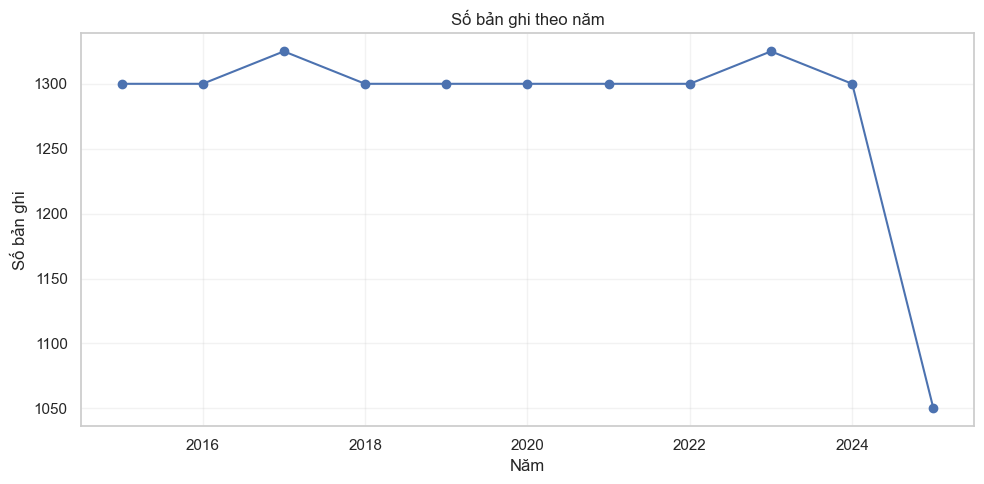


### Hình 01 - Số bản ghi theo năm

**Tệp đã lưu**
- `figure_01_records_by_year.png`


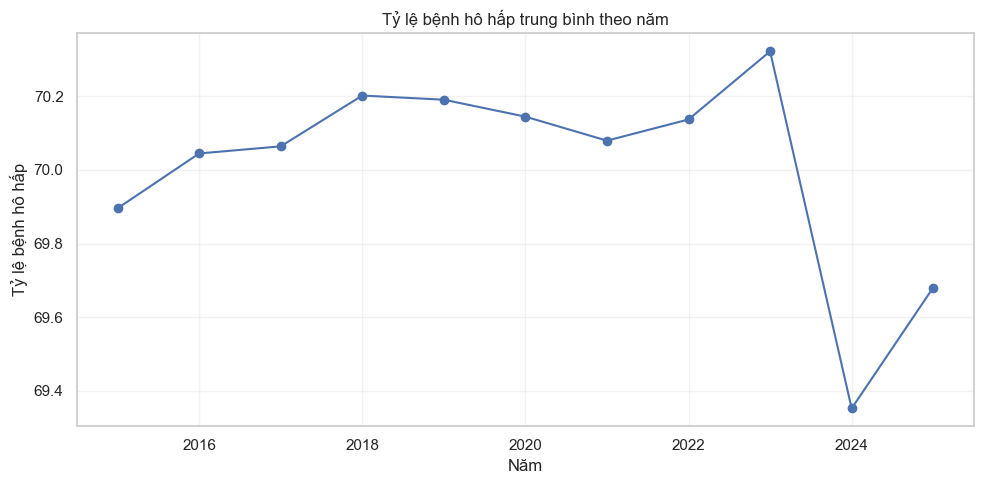


### Hình 02 - Tỷ lệ bệnh hô hấp trung bình theo năm

**Tệp đã lưu**
- `figure_02_annual_respiratory_trend.png`


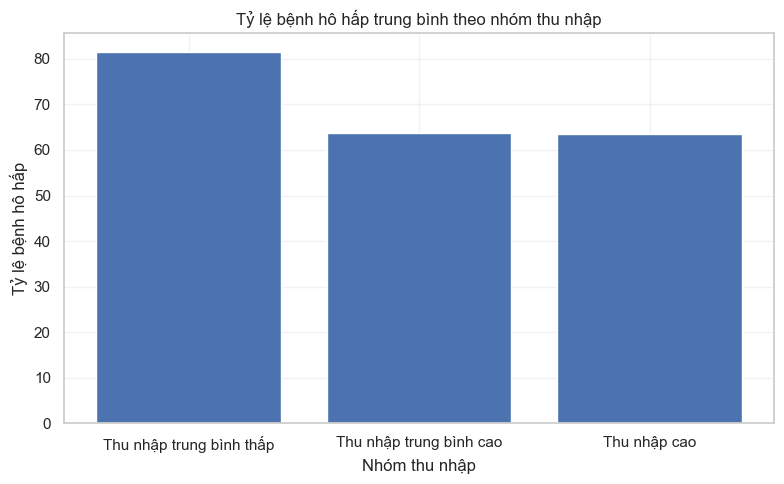


### Hình 03 - Tỷ lệ bệnh hô hấp trung bình theo nhóm thu nhập

**Tệp đã lưu**
- `figure_03_respiratory_by_income.png`


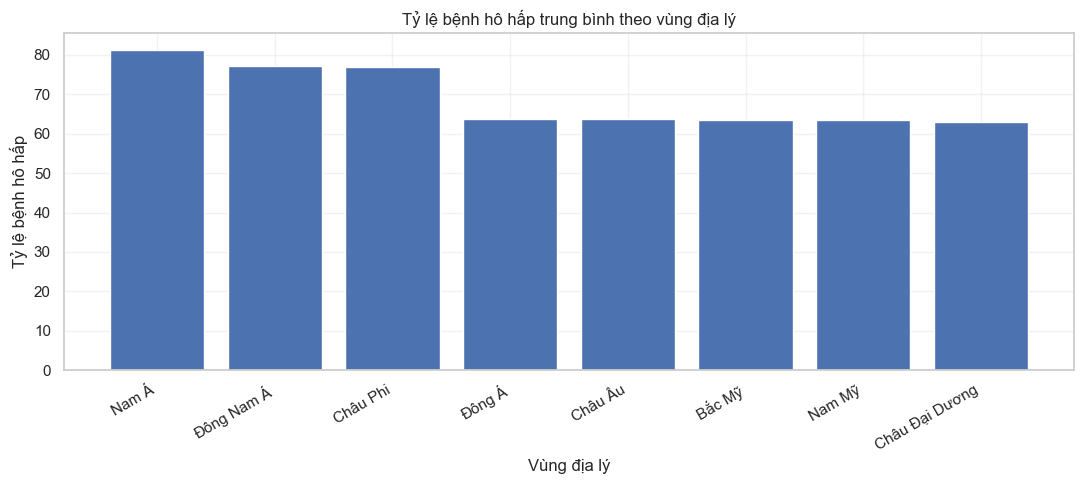


### Hình 04 - Tỷ lệ bệnh hô hấp trung bình theo vùng địa lý

**Tệp đã lưu**
- `figure_04_respiratory_by_region.png`



### Bảng 06 - Một số hệ số tương quan quan trọng với tỷ lệ bệnh hô hấp

**Tệp đã lưu**
- `tables/table_06_selected_correlation_matrix.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_06_selected_correlation_matrix.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_06_selected_correlation_matrix.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Biến số,Hệ số tương quan
0,PM2.5 (µg/m³),0.7590
1,Chỉ số chất lượng không khí,0.7360
2,Nhiệt độ trung bình (°C),0.2315
3,Bất thường nhiệt độ (°C),-0.0080
4,Lượng mưa (mm),-0.1421
5,Số ngày nắng nóng,0.0027
6,Số sự kiện thời tiết cực đoan,0.0064
7,Chỉ số tiếp cận y tế,-0.4969
8,GDP bình quân đầu người (USD),-0.3774
9,Chỉ số an ninh lương thực,-0.3734


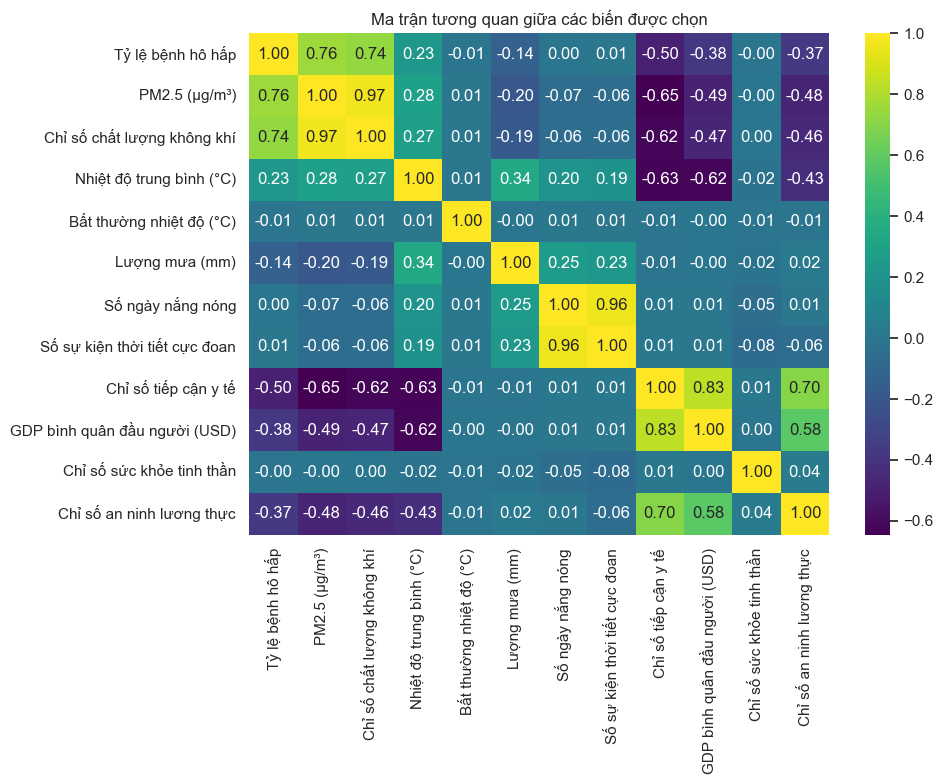


### Hình 05 - Ma trận tương quan giữa các biến được chọn

**Tệp đã lưu**
- `figure_05_correlation_heatmap.png`


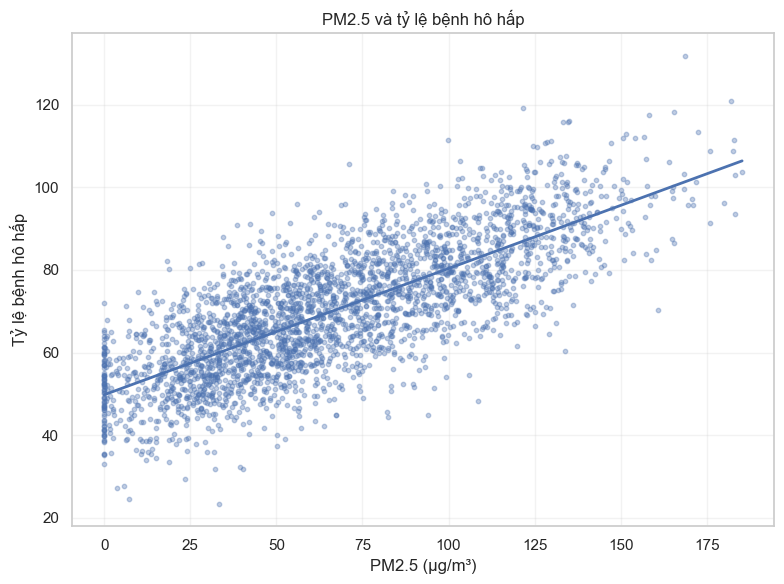


### Hình 06 - PM2.5 và tỷ lệ bệnh hô hấp

**Tệp đã lưu**
- `figure_06_pm25_vs_respiratory.png`


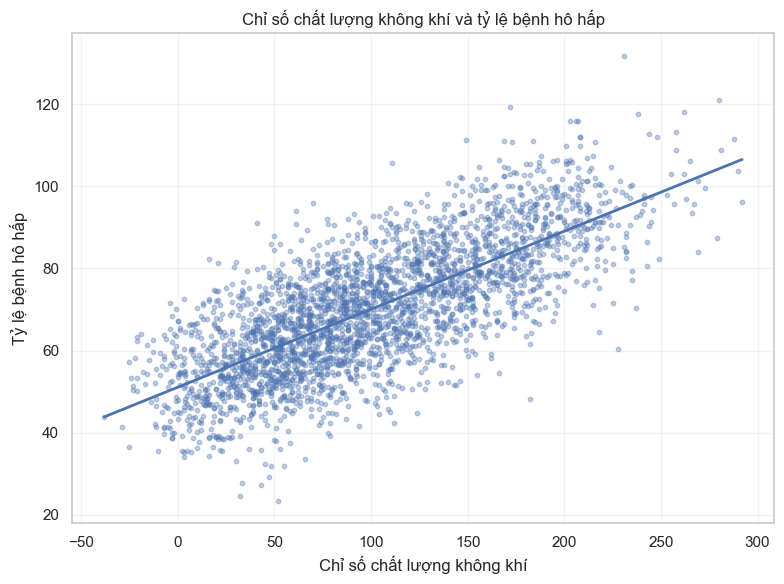


### Hình 07 - Chỉ số chất lượng không khí và tỷ lệ bệnh hô hấp

**Tệp đã lưu**
- `figure_07_aqi_vs_respiratory.png`


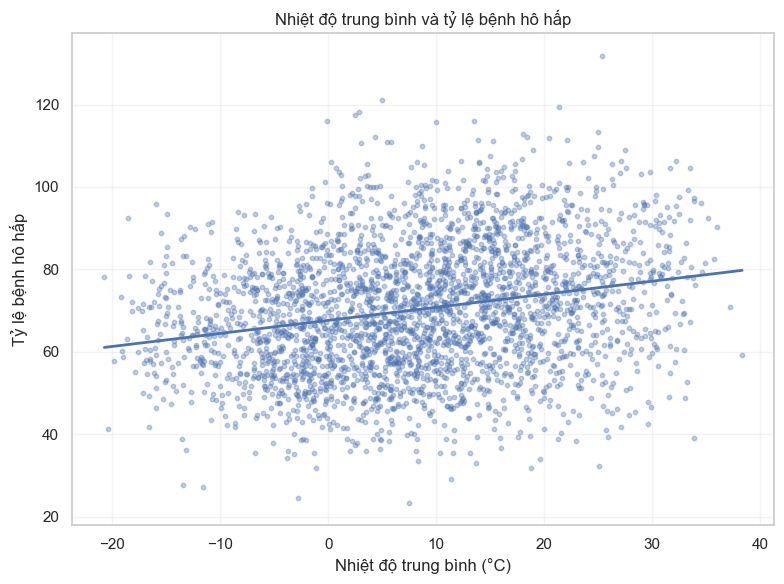


### Hình 08 - Nhiệt độ trung bình và tỷ lệ bệnh hô hấp

**Tệp đã lưu**
- `figure_08_temperature_vs_respiratory.png`


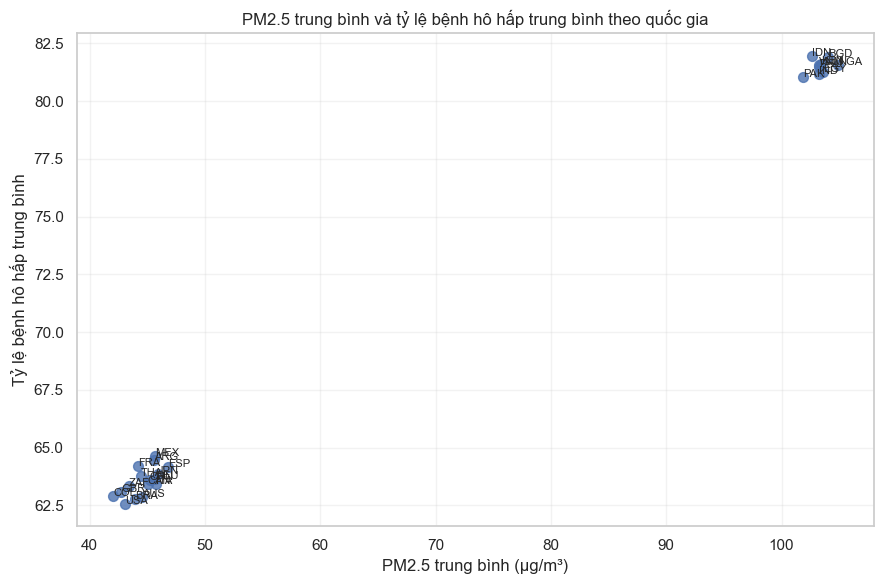


### Hình 09 - PM2.5 trung bình và tỷ lệ bệnh hô hấp trung bình theo quốc gia

**Tệp đã lưu**
- `figure_09_country_pm25_vs_resp.png`


In [6]:
# =========================
# 5) Exploratory data analysis (EDA)
# =========================
print_step("STEP 3 - Exploratory data analysis (EDA)")

# -------------------------
# 5.1 EDA overview figures
# -------------------------

# Figure 01: records by year
records_by_year = df.groupby("year").size().reset_index(name="n_records")
plt.figure(figsize=(10, 5))
plt.plot(records_by_year["year"], records_by_year["n_records"], marker="o")
plt.title("Số bản ghi theo năm")
plt.xlabel("Năm")
plt.ylabel("Số bản ghi")
plt.grid(alpha=0.25)
finalize_figure(os.path.join(FIG_DIR, "figure_01_records_by_year.png"))
show_saved_figure("Hình 01 - Số bản ghi theo năm", "figure_01_records_by_year")

# Figure 02: annual respiratory trend
annual_resp = df.groupby("year", as_index=False)["respiratory_disease_rate"].mean()
plt.figure(figsize=(10, 5))
plt.plot(annual_resp["year"], annual_resp["respiratory_disease_rate"], marker="o")
plt.title("Tỷ lệ bệnh hô hấp trung bình theo năm")
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ bệnh hô hấp")
plt.grid(alpha=0.25)
finalize_figure(os.path.join(FIG_DIR, "figure_02_annual_respiratory_trend.png"))
show_saved_figure("Hình 02 - Tỷ lệ bệnh hô hấp trung bình theo năm", "figure_02_annual_respiratory_trend")

# Figure 03: respiratory by income level
income_resp = (
    df.groupby("income_level", as_index=False)["respiratory_disease_rate"]
      .mean()
      .sort_values("respiratory_disease_rate", ascending=False)
)
plt.figure(figsize=(8, 5))
income_resp["income_level_vi"] = income_resp["income_level"].map(lambda x: vi_label(x))
plt.bar(income_resp["income_level_vi"], income_resp["respiratory_disease_rate"])
plt.title("Tỷ lệ bệnh hô hấp trung bình theo nhóm thu nhập")
plt.xlabel("Nhóm thu nhập")
plt.ylabel("Tỷ lệ bệnh hô hấp")
finalize_figure(os.path.join(FIG_DIR, "figure_03_respiratory_by_income.png"))
show_saved_figure("Hình 03 - Tỷ lệ bệnh hô hấp trung bình theo nhóm thu nhập", "figure_03_respiratory_by_income")

# Figure 04: respiratory by region
region_resp = (
    df.groupby("region", as_index=False)["respiratory_disease_rate"]
      .mean()
      .sort_values("respiratory_disease_rate", ascending=False)
)
plt.figure(figsize=(11, 5))
region_resp["region_vi"] = region_resp["region"].map(lambda x: vi_label(x))
plt.bar(region_resp["region_vi"], region_resp["respiratory_disease_rate"])
plt.title("Tỷ lệ bệnh hô hấp trung bình theo vùng địa lý")
plt.xlabel("Vùng địa lý")
plt.ylabel("Tỷ lệ bệnh hô hấp")
plt.xticks(rotation=30, ha="right")
finalize_figure(os.path.join(FIG_DIR, "figure_04_respiratory_by_region.png"))
show_saved_figure("Hình 04 - Tỷ lệ bệnh hô hấp trung bình theo vùng địa lý", "figure_04_respiratory_by_region")


# -----------------------------------------
# 5.2 Correlation and bivariate exploration
# -----------------------------------------

corr_vars = [
    "respiratory_disease_rate", "pm25_ugm3", "air_quality_index", "temperature_celsius",
    "temp_anomaly_celsius", "precipitation_mm", "heat_wave_days", "extreme_weather_events",
    "healthcare_access_index", "gdp_per_capita_usd", "mental_health_index", "food_security_index"
]

corr_matrix = df[corr_vars].corr(numeric_only=True)

target_corr_vars = [
    "pm25_ugm3",
    "air_quality_index",
    "temperature_celsius",
    "temp_anomaly_celsius",
    "precipitation_mm",
    "heat_wave_days",
    "extreme_weather_events",
    "healthcare_access_index",
    "gdp_per_capita_usd",
    "food_security_index",
]

target_corr_summary = pd.DataFrame({
    "Biến số": target_corr_vars,
    "Hệ số tương quan": [
        f"{corr_matrix.loc[var, 'respiratory_disease_rate']:.4f}"
        for var in target_corr_vars
    ],
})

show_saved_table(
    target_corr_summary,
    title="Bảng 06 - Một số hệ số tương quan quan trọng với tỷ lệ bệnh hô hấp",
    stem="table_06_selected_correlation_matrix",
    index=False,
)

# Optional source table: full matrix for checking/reproducibility.
save_df(
    corr_matrix.reset_index(),
    "supp_02_selected_correlation_matrix_full",
    index=False,
)

plt.figure(figsize=(10, 8))
corr_matrix_vi = corr_matrix.rename(index=lambda x: vi_label(x), columns=lambda x: vi_label(x))
sns.heatmap(corr_matrix_vi, annot=True, fmt=".2f", cmap="viridis")
plt.title("Ma trận tương quan giữa các biến được chọn")
finalize_figure(os.path.join(FIG_DIR, "figure_05_correlation_heatmap.png"))
show_saved_figure("Hình 05 - Ma trận tương quan giữa các biến được chọn", "figure_05_correlation_heatmap")

# Sample for scatter plots
sample_df = df.sample(min(3000, len(df)), random_state=SEED).copy()

# Figure 06: PM2.5 vs respiratory
plt.figure(figsize=(8, 6))
plt.scatter(sample_df["pm25_ugm3"], sample_df["respiratory_disease_rate"], s=10, alpha=0.35)
z = np.polyfit(sample_df["pm25_ugm3"], sample_df["respiratory_disease_rate"], 1)
p = np.poly1d(z)
xs = np.linspace(sample_df["pm25_ugm3"].min(), sample_df["pm25_ugm3"].max(), 100)
plt.plot(xs, p(xs), linewidth=2)
plt.title("PM2.5 và tỷ lệ bệnh hô hấp")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Tỷ lệ bệnh hô hấp")
finalize_figure(os.path.join(FIG_DIR, "figure_06_pm25_vs_respiratory.png"))
show_saved_figure("Hình 06 - PM2.5 và tỷ lệ bệnh hô hấp", "figure_06_pm25_vs_respiratory")

# Figure 07: AQI vs respiratory
plt.figure(figsize=(8, 6))
plt.scatter(sample_df["air_quality_index"], sample_df["respiratory_disease_rate"], s=10, alpha=0.35)
z = np.polyfit(sample_df["air_quality_index"], sample_df["respiratory_disease_rate"], 1)
p = np.poly1d(z)
xs = np.linspace(sample_df["air_quality_index"].min(), sample_df["air_quality_index"].max(), 100)
plt.plot(xs, p(xs), linewidth=2)
plt.title("Chỉ số chất lượng không khí và tỷ lệ bệnh hô hấp")
plt.xlabel("Chỉ số chất lượng không khí")
plt.ylabel("Tỷ lệ bệnh hô hấp")
finalize_figure(os.path.join(FIG_DIR, "figure_07_aqi_vs_respiratory.png"))
show_saved_figure("Hình 07 - Chỉ số chất lượng không khí và tỷ lệ bệnh hô hấp", "figure_07_aqi_vs_respiratory")

# Figure 08: Temperature vs respiratory
plt.figure(figsize=(8, 6))
plt.scatter(sample_df["temperature_celsius"], sample_df["respiratory_disease_rate"], s=10, alpha=0.35)
z = np.polyfit(sample_df["temperature_celsius"], sample_df["respiratory_disease_rate"], 1)
p = np.poly1d(z)
xs = np.linspace(sample_df["temperature_celsius"].min(), sample_df["temperature_celsius"].max(), 100)
plt.plot(xs, p(xs), linewidth=2)
plt.title("Nhiệt độ trung bình và tỷ lệ bệnh hô hấp")
plt.xlabel("Nhiệt độ trung bình (°C)")
plt.ylabel("Tỷ lệ bệnh hô hấp")
finalize_figure(os.path.join(FIG_DIR, "figure_08_temperature_vs_respiratory.png"))
show_saved_figure("Hình 08 - Nhiệt độ trung bình và tỷ lệ bệnh hô hấp", "figure_08_temperature_vs_respiratory")


# -------------------------
# 5.3 Country-level summary
# -------------------------

country_summary = (
    df.groupby(["country_code", "country_name", "region", "income_level"], as_index=False)
      .agg(
          mean_resp=("respiratory_disease_rate", "mean"),
          mean_pm25=("pm25_ugm3", "mean"),
          mean_aqi=("air_quality_index", "mean"),
      )
)

save_df(
    country_summary,
    "table_07_country_summary",
    index=False
)

plt.figure(figsize=(9, 6))
plt.scatter(country_summary["mean_pm25"], country_summary["mean_resp"], s=50, alpha=0.8)
for _, row in country_summary.iterrows():
    plt.annotate(row["country_code"], (row["mean_pm25"], row["mean_resp"]), fontsize=8)
plt.title("PM2.5 trung bình và tỷ lệ bệnh hô hấp trung bình theo quốc gia")
plt.xlabel("PM2.5 trung bình (µg/m³)")
plt.ylabel("Tỷ lệ bệnh hô hấp trung bình")
finalize_figure(os.path.join(FIG_DIR, "figure_09_country_pm25_vs_resp.png"))
show_saved_figure("Hình 09 - PM2.5 trung bình và tỷ lệ bệnh hô hấp trung bình theo quốc gia", "figure_09_country_pm25_vs_resp")



In [7]:
# =========================
# 6) Feature engineering
# =========================
print_step("STEP 4 - Feature engineering for AQM-Lag")

# Work on a country-time sorted copy so lag and rolling features are computed correctly within each country.
work_df = df.sort_values(["country_name", "date"]).copy()

# 6.1 Lag features: use only previous weeks within country.
lag_source_cols = [
    "respiratory_disease_rate", "pm25_ugm3", "air_quality_index",
    "temperature_celsius", "temp_anomaly_celsius", "precipitation_mm",
    "heat_wave_days", "extreme_weather_events"
]

lagged_feature_names = []
for lag in [1, 2, 4]:
    for col in lag_source_cols:
        new_col = f"{col}_lag{lag}"
        work_df[new_col] = work_df.groupby("country_name")[col].shift(lag)
        lagged_feature_names.append(new_col)

# 6.2 Rolling mean features: shift first to avoid current-week leakage.
rolling_source_cols = [
    "respiratory_disease_rate", "pm25_ugm3",
    "air_quality_index", "temp_anomaly_celsius"
]

rolling_feature_names = []
for col in rolling_source_cols:
    new_col = f"{col}_roll4_mean"
    work_df[new_col] = (
        work_df.groupby("country_name")[col]
        .transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
    )
    rolling_feature_names.append(new_col)

# Supplementary note: target lag features are valid in a weekly surveillance setting.
target_lag_note = pd.DataFrame([
    {
        "item": "target_lag_features",
        "description": "Lagged respiratory_disease_rate features use previous-week values only; current-week target is not used as input."
    },
    {
        "item": "intended_use",
        "description": "Suitable for periodic surveillance or short-term forecasting when historical respiratory rates are available."
    }
])
save_df(target_lag_note, "supp_04_target_lag_assumption", index=False)

# 6.3 Seasonal encoding.
work_df["season_sin"] = np.sin(2 * np.pi * work_df["week"] / 52.0)
work_df["season_cos"] = np.cos(2 * np.pi * work_df["week"] / 52.0)

# 6.4 Fixed time-based split.
train_df = work_df[work_df["year"] <= 2021].copy()
val_df = work_df[(work_df["year"] >= 2022) & (work_df["year"] <= 2023)].copy()
test_df = work_df[work_df["year"] >= 2024].copy()

split_table = pd.DataFrame([
    {"split": "train", "year_range": "2015-2021", "n_rows": len(train_df)},
    {"split": "validation", "year_range": "2022-2023", "n_rows": len(val_df)},
    {"split": "test", "year_range": "2024-2025", "n_rows": len(test_df)},
])

show_saved_table(
    split_table,
    title="Bảng 08 - Phân chia dữ liệu theo thời gian",
    stem="table_08_time_split",
    index=False
)

# Supplementary missingness caused by lag/rolling construction.
lag_rolling_feature_names = lagged_feature_names + rolling_feature_names
lag_missing_summary = pd.DataFrame({
    "feature": lag_rolling_feature_names,
    "train_missing": train_df[lag_rolling_feature_names].isna().sum().values,
    "validation_missing": val_df[lag_rolling_feature_names].isna().sum().values,
    "test_missing": test_df[lag_rolling_feature_names].isna().sum().values,
})
lag_missing_summary["note"] = (
    "Missing values are expected for early weeks after lag/rolling feature creation "
    "and are handled by SimpleImputer in the pipeline."
)
save_df(lag_missing_summary, "supp_05_lag_rolling_missing_summary", index=False)

# 6.5 AQM Stress Index: standardize with train statistics only.
stress_vars = [
    "pm25_ugm3", "air_quality_index", "temp_anomaly_celsius",
    "heat_wave_days", "extreme_weather_events"
]
stress_weights = {
    "pm25_ugm3": 0.35,
    "air_quality_index": 0.25,
    "temp_anomaly_celsius": 0.15,
    "heat_wave_days": 0.15,
    "extreme_weather_events": 0.10,
}

stress_weight_table = pd.DataFrame([
    {"component": k, "weight": v}
    for k, v in stress_weights.items()
])

show_saved_table(
    stress_weight_table,
    title="Phụ lục - Thành phần và trọng số của chỉ số căng thẳng AQM",
    stem="supp_aqm_stress_weights",
    index=False
)

train_means = {c: float(train_df[c].mean()) for c in stress_vars}
train_stds = {
    c: float(train_df[c].std(ddof=0)) if float(train_df[c].std(ddof=0)) > 0 else 1.0
    for c in stress_vars
}

for part_df in [train_df, val_df, test_df]:
    for c in stress_vars:
        part_df[f"z_{c}"] = (part_df[c] - train_means[c]) / train_stds[c]
    part_df["aqm_stress_index"] = sum(stress_weights[c] * part_df[f"z_{c}"] for c in stress_vars)

    # Simple interaction terms used by the proposed AQM-Lag feature set.
    part_df["pm25_x_temperature"] = part_df["pm25_ugm3"] * part_df["temperature_celsius"]
    part_df["aqi_x_heatwave"] = part_df["air_quality_index"] * (part_df["heat_wave_days"] + 1)
    part_df["precip_x_flood"] = part_df["precipitation_mm"] * (part_df["flood_indicator"] + 1)

# Supplementary missingness after all feature engineering steps.
fe_missing_table = pd.DataFrame([
    {
        "split": "train",
        "year_range": "2015-2021",
        "n_rows": len(train_df),
        "missing_values": int(train_df.isna().sum().sum()),
        "missing_percent": round(train_df.isna().mean().mean() * 100, 4)
    },
    {
        "split": "validation",
        "year_range": "2022-2023",
        "n_rows": len(val_df),
        "missing_values": int(val_df.isna().sum().sum()),
        "missing_percent": round(val_df.isna().mean().mean() * 100, 4)
    },
    {
        "split": "test",
        "year_range": "2024-2025",
        "n_rows": len(test_df),
        "missing_values": int(test_df.isna().sum().sum()),
        "missing_percent": round(test_df.isna().mean().mean() * 100, 4)
    },
])
save_df(fe_missing_table, "supp_06_missing_after_feature_engineering", index=False)

# 6.6 Feature set definitions.
base_features = [
    "country_name", "region", "income_level", "year", "month", "week",
    "temperature_celsius", "temp_anomaly_celsius", "precipitation_mm", "heat_wave_days",
    "drought_indicator", "flood_indicator", "extreme_weather_events",
    "pm25_ugm3", "air_quality_index", "healthcare_access_index",
    "gdp_per_capita_usd", "mental_health_index", "food_security_index"
]

lag_features = base_features + [
    "season_sin", "season_cos",
    "respiratory_disease_rate_lag1", "respiratory_disease_rate_lag2", "respiratory_disease_rate_lag4",
    "pm25_ugm3_lag1", "pm25_ugm3_lag2", "pm25_ugm3_lag4",
    "air_quality_index_lag1", "air_quality_index_lag2", "air_quality_index_lag4",
    "temperature_celsius_lag1", "temperature_celsius_lag2", "temperature_celsius_lag4",
    "temp_anomaly_celsius_lag1", "temp_anomaly_celsius_lag2", "temp_anomaly_celsius_lag4",
    "precipitation_mm_lag1", "precipitation_mm_lag2", "precipitation_mm_lag4",
    "heat_wave_days_lag1", "heat_wave_days_lag2", "heat_wave_days_lag4",
    "extreme_weather_events_lag1", "extreme_weather_events_lag2", "extreme_weather_events_lag4",
    "respiratory_disease_rate_roll4_mean", "pm25_ugm3_roll4_mean",
    "air_quality_index_roll4_mean", "temp_anomaly_celsius_roll4_mean"
]

proposed_aqm_lag_features = lag_features + [
    "aqm_stress_index", "pm25_x_temperature", "aqi_x_heatwave", "precip_x_flood"
]

# Early validation: fail fast if any feature was misspelled or not created.
assert_columns_exist(train_df, base_features, "train_df/base_features")
assert_columns_exist(train_df, lag_features, "train_df/lag_features")
assert_columns_exist(train_df, proposed_aqm_lag_features, "train_df/proposed_aqm_lag_features")

feature_catalog = pd.DataFrame([
    {"feature_set": "baseline_raw", "n_features": len(base_features), "description": "Raw current-week variables"},
    {"feature_set": "lag_enhanced", "n_features": len(lag_features), "description": "Raw variables plus lag, rolling and seasonal features"},
    {"feature_set": "AQM_Lag_proposed", "n_features": len(proposed_aqm_lag_features), "description": "Lag-enhanced features plus AQM stress index and simple interaction terms"},
])

show_saved_table(
    feature_catalog,
    title="Bảng 09 - Danh mục các bộ đặc trưng",
    stem="table_09_feature_catalog",
    index=False
)


STEP 4 - Feature engineering for AQM-Lag



### Bảng 08 - Phân chia dữ liệu theo thời gian

**Tệp đã lưu**
- `tables/table_08_time_split.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_08_time_split.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_08_time_split.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Tập dữ liệu,Khoảng năm,Số dòng
0,Huấn luyện,2015-2021,9.125
1,Kiểm định,2022-2023,2.625
2,Kiểm tra,2024-2025,2.350



### Phụ lục - Thành phần và trọng số của chỉ số căng thẳng AQM

**Tệp đã lưu**
- `tables/supp_aqm_stress_weights.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/supp_aqm_stress_weights.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/supp_aqm_stress_weights.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Thành phần,Trọng số
0,PM2.5 (µg/m³),0.35
1,Chỉ số chất lượng không khí,0.25
2,Bất thường nhiệt độ (°C),0.15
3,Số ngày nắng nóng,0.15
4,Số sự kiện thời tiết cực đoan,0.1



### Bảng 09 - Danh mục các bộ đặc trưng

**Tệp đã lưu**
- `tables/table_09_feature_catalog.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_09_feature_catalog.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_09_feature_catalog.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Bộ đặc trưng,Số biến,Mô tả
0,Bộ đặc trưng gốc,19,Các biến gốc tại tuần hiện tại
1,Bộ đặc trưng có độ trễ,49,"Các biến gốc kết hợp đặc trưng độ trễ, trung\n..."
2,Bộ đặc trưng AQM-Lag đề xuất,53,Bộ đặc trưng có độ trễ kết hợp chỉ số căng thẳ...



STEP 5 - Modeling and evaluation



### Bảng 15 - Kết quả kiểm định tốt nhất theo bộ đặc trưng trong phân tích loại/bổ sung đặc trưng

**Tệp đã lưu**
- `tables/table_15_ablation_best_by_feature_set.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_15_ablation_best_by_feature_set.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_15_ablation_best_by_feature_set.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Bộ đặc trưng,Mô hình,RMSE,MAE,R²,MAPE (%)
0,Bộ đặc trưng AQM-Lag đề xuất,Hồi quy Ridge,9.976,8.056,0.581,12.385
1,Bộ đặc trưng gốc,Hồi quy Ridge,9.959,8.034,0.583,12.366
2,Bộ đặc trưng có độ trễ,Hồi quy Ridge,9.975,8.055,0.581,12.386


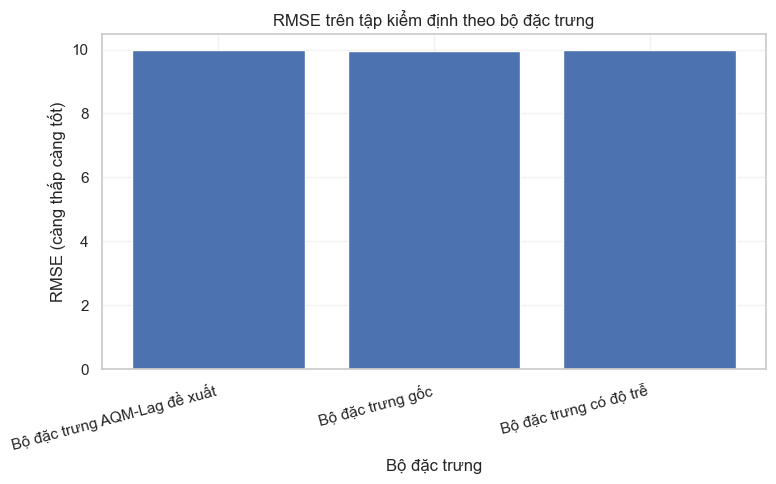


### Hình 14 - RMSE trên tập kiểm định theo bộ đặc trưng

**Tệp đã lưu**
- `figure_14_validation_rmse_by_feature_set.png`



### Bảng 11 - Xếp hạng mô hình trên tập kiểm định với bộ đặc trưng AQM-Lag đề xuất

**Tệp đã lưu**
- `tables/table_11_validation_model_ranking.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_11_validation_model_ranking.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_11_validation_model_ranking.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Bộ đặc trưng,Mô hình,Tập dữ liệu,Giai đoạn,MAE,RMSE,R²,MAPE (%)
0,Bộ đặc trưng AQM-Lag đề xuất,Hồi quy Ridge,Kiểm định,So sánh mô hình,8.056,9.976,0.581,12.385
1,Bộ đặc trưng AQM-Lag đề xuất,Rừng ngẫu nhiên,Kiểm định,So sánh mô hình,8.162,10.106,0.57,12.553
2,Bộ đặc trưng AQM-Lag đề xuất,Cây cực ngẫu nhiên,Kiểm định,So sánh mô hình,8.211,10.185,0.564,12.627



### Bảng 12 - Xếp hạng mô hình trên tập kiểm tra với bộ đặc trưng AQM-Lag đề xuất

**Tệp đã lưu**
- `tables/table_12_test_model_ranking.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_12_test_model_ranking.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_12_test_model_ranking.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Bộ đặc trưng,Mô hình,Tập dữ liệu,Giai đoạn,MAE,RMSE,R²,MAPE (%)
0,Bộ đặc trưng AQM-Lag đề xuất,Hồi quy Ridge,Kiểm tra,So sánh mô hình,7.942,9.969,0.576,12.489
1,Bộ đặc trưng AQM-Lag đề xuất,Rừng ngẫu nhiên,Kiểm tra,So sánh mô hình,8.045,10.073,0.568,12.605
2,Bộ đặc trưng AQM-Lag đề xuất,Cây cực ngẫu nhiên,Kiểm tra,So sánh mô hình,8.101,10.19,0.557,12.711



### Bảng - Thiết kế thực nghiệm và cấu hình mô hình trong kịch bản

**Tệp đã lưu**
- `tables/table_model_configuration.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/table_model_configuration.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/table_model_configuration.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Thành phần,Phạm vi sử dụng,Thiết lập trong kịch bản
0,Ridge Regression,Kiểm định bộ đặc trưng và so sánh mô hình,alpha = 1.5
1,Random Forest Regressor,So sánh mô hình trên AQM_Lag_proposed,"n_estimators = 80, max_depth = 14,\nmin_sample..."
2,Extra Trees Regressor,So sánh mô hình trên AQM_Lag_proposed,"n_estimators = 100, min_samples_leaf = 1,\nran..."


[INFO] Mô hình tốt nhất trên tập kiểm định: Hồi quy Ridge + Bộ đặc trưng AQM-Lag đề xuất


In [8]:
# =========================
# 7) Modeling
# =========================
print_step("STEP 5 - Modeling and evaluation")

TARGET = "respiratory_disease_rate"
feature_sets = {
    "baseline_raw": base_features,
    "lag_enhanced": lag_features,
    "AQM_Lag_proposed": proposed_aqm_lag_features,
}

# Part A: feature-set ablation.
# Keep Ridge as the default to test whether the feature representation itself adds value.
# You may add more models here, but the thesis text should then state that ablation used multiple estimators.
ablation_models = {
    "Ridge": Ridge(alpha=1.5),
}

# Part B: model comparison on the proposed AQM-Lag feature set.
proposal_models = {
    "Ridge": Ridge(alpha=1.5),
    "RandomForest": RandomForestRegressor(
        n_estimators=80,
        max_depth=14,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=100,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=SEED,
    ),
}

all_scores = []
trained_objects = {}

# 7.1 Feature-set ablation.
for feature_set_name, feature_list in feature_sets.items():
    X_train = train_df[feature_list].copy()
    X_val = val_df[feature_list].copy()
    X_test = test_df[feature_list].copy()
    y_train = train_df[TARGET].copy()
    y_val = val_df[TARGET].copy()
    y_test = test_df[TARGET].copy()

    for ablation_model_name, ablation_model in ablation_models.items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor(X_train)),
                ("model", ablation_model),
            ]
        )
        pipeline.fit(X_train, y_train)

        pred_val = pipeline.predict(X_val)
        pred_test = pipeline.predict(X_test)

        all_scores.extend([
            {
                "feature_set": feature_set_name,
                "model": ablation_model_name,
                "split": "validation",
                "phase": "feature_ablation",
                "MAE": mean_absolute_error(y_val, pred_val),
                "RMSE": rmse(y_val, pred_val),
                "R2": r2_score(y_val, pred_val),
                "MAPE_percent": mape(y_val, pred_val),
            },
            {
                "feature_set": feature_set_name,
                "model": ablation_model_name,
                "split": "test",
                "phase": "feature_ablation",
                "MAE": mean_absolute_error(y_test, pred_test),
                "RMSE": rmse(y_test, pred_test),
                "R2": r2_score(y_test, pred_test),
                "MAPE_percent": mape(y_test, pred_test),
            }
        ])

        trained_objects[(feature_set_name, ablation_model_name, "feature_ablation")] = {
            "pipeline": pipeline,
            "feature_list": feature_list,
            "pred_val": pred_val,
            "pred_test": pred_test,
        }

# 7.2 Model comparison on AQM_Lag_proposed.
feature_set_name = "AQM_Lag_proposed"
feature_list = feature_sets[feature_set_name]
X_train = train_df[feature_list].copy()
X_val = val_df[feature_list].copy()
X_test = test_df[feature_list].copy()
y_train = train_df[TARGET].copy()
y_val = val_df[TARGET].copy()
y_test = test_df[TARGET].copy()

for model_name, model in proposal_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(X_train)),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)

    pred_val = pipeline.predict(X_val)
    pred_test = pipeline.predict(X_test)

    all_scores.extend([
        {
            "feature_set": feature_set_name,
            "model": model_name,
            "split": "validation",
            "phase": "model_comparison",
            "MAE": mean_absolute_error(y_val, pred_val),
            "RMSE": rmse(y_val, pred_val),
            "R2": r2_score(y_val, pred_val),
            "MAPE_percent": mape(y_val, pred_val),
        },
        {
            "feature_set": feature_set_name,
            "model": model_name,
            "split": "test",
            "phase": "model_comparison",
            "MAE": mean_absolute_error(y_test, pred_test),
            "RMSE": rmse(y_test, pred_test),
            "R2": r2_score(y_test, pred_test),
            "MAPE_percent": mape(y_test, pred_test),
        }
    ])

    trained_objects[(feature_set_name, model_name, "model_comparison")] = {
        "pipeline": pipeline,
        "feature_list": feature_list,
        "pred_val": pred_val,
        "pred_test": pred_test,
    }

# 7.3 Save evaluation tables.
scores_df = pd.DataFrame(all_scores)
scores_df = scores_df.sort_values(
    ["split", "phase", "RMSE", "MAE"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# Full long-format scores are supplementary because they contain all phases and splits.
save_df(scores_df, "table_10_model_scores_long", index=False)

ablation_val = (
    scores_df[(scores_df["split"] == "validation") & (scores_df["phase"] == "feature_ablation")]
    .sort_values(["feature_set", "RMSE", "MAE", "R2"], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

# If ablation_models has multiple models, this keeps the best model per feature set.
ablation_best = (
    ablation_val
    .sort_values(["feature_set", "RMSE", "MAE", "R2"], ascending=[True, True, True, False])
    .groupby("feature_set", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

show_saved_table(
    ablation_best[["feature_set", "model", "RMSE", "MAE", "R2", "MAPE_percent"]],
    title="Bảng 15 - Kết quả kiểm định tốt nhất theo bộ đặc trưng trong phân tích loại/bổ sung đặc trưng",
    stem="table_15_ablation_best_by_feature_set",
    index=False
)

# Figure 14: validation RMSE by feature-set design.
plt.figure(figsize=(8, 5))
plt.bar(ablation_best["feature_set"].map(lambda x: vi_label(x)), ablation_best["RMSE"])
plt.title("RMSE trên tập kiểm định theo bộ đặc trưng")
plt.xlabel("Bộ đặc trưng")
plt.ylabel("RMSE (càng thấp càng tốt)")
plt.xticks(rotation=15, ha="right")
finalize_figure(os.path.join(FIG_DIR, "figure_14_validation_rmse_by_feature_set.png"))
show_saved_figure("Hình 14 - RMSE trên tập kiểm định theo bộ đặc trưng", "figure_14_validation_rmse_by_feature_set")

val_rank = (
    scores_df[(scores_df["split"] == "validation") & (scores_df["phase"] == "model_comparison")]
    .sort_values(["RMSE", "MAE", "R2"], ascending=[True, True, False])
    .reset_index(drop=True)
)

test_rank = (
    scores_df[(scores_df["split"] == "test") & (scores_df["phase"] == "model_comparison")]
    .sort_values(["RMSE", "MAE", "R2"], ascending=[True, True, False])
    .reset_index(drop=True)
)

show_saved_table(
    val_rank,
    title="Bảng 11 - Xếp hạng mô hình trên tập kiểm định với bộ đặc trưng AQM-Lag đề xuất",
    stem="table_11_validation_model_ranking",
    index=False
)

show_saved_table(
    test_rank,
    title="Bảng 12 - Xếp hạng mô hình trên tập kiểm tra với bộ đặc trưng AQM-Lag đề xuất",
    stem="table_12_test_model_ranking",
    index=False
)

# Final model is selected only from the proposed-feature model-comparison phase.
best_feature_set = val_rank.loc[0, "feature_set"]
best_model_name = val_rank.loc[0, "model"]

# PDF Table 3.5.2: model configuration used in the experimental scenario.
model_configuration = pd.DataFrame([
    {
        "Thành phần": "Ridge Regression",
        "Phạm vi sử dụng": "Kiểm định bộ đặc trưng và so sánh mô hình",
        "Thiết lập trong kịch bản": "alpha = 1.5",
    },
    {
        "Thành phần": "Random Forest Regressor",
        "Phạm vi sử dụng": "So sánh mô hình trên AQM_Lag_proposed",
        "Thiết lập trong kịch bản": "n_estimators = 80, max_depth = 14, min_samples_leaf = 2, random_state = 42",
    },
    {
        "Thành phần": "Extra Trees Regressor",
        "Phạm vi sử dụng": "So sánh mô hình trên AQM_Lag_proposed",
        "Thiết lập trong kịch bản": "n_estimators = 100, min_samples_leaf = 1, random_state = 42",
    },
])

show_saved_table(
    model_configuration,
    title="Bảng - Thiết kế thực nghiệm và cấu hình mô hình trong kịch bản",
    stem="table_model_configuration",
    index=False,
)

best_obj = trained_objects[(best_feature_set, best_model_name, "model_comparison")]
best_pipeline = best_obj["pipeline"]
best_features = best_obj["feature_list"]

print(f"[INFO] Mô hình tốt nhất trên tập kiểm định: {vi_label(best_model_name)} + {vi_label(best_feature_set)}")

joblib.dump(best_pipeline, os.path.join(MODEL_DIR, "best_model.joblib"))
save_text(
    json.dumps(
        {
            "best_feature_set": best_feature_set,
            "best_model_name": best_model_name,
            "n_features": len(best_features),
            "selection_phase": "model_comparison",
        },
        ensure_ascii=False,
        indent=2
    ),
    os.path.join(MODEL_DIR, "best_model_info.json")
)


STEP 6 - Best model diagnostics
[INFO] DOCX table skipped for table_13_test_predictions because it has 2350 rows > 120. CSV was saved.


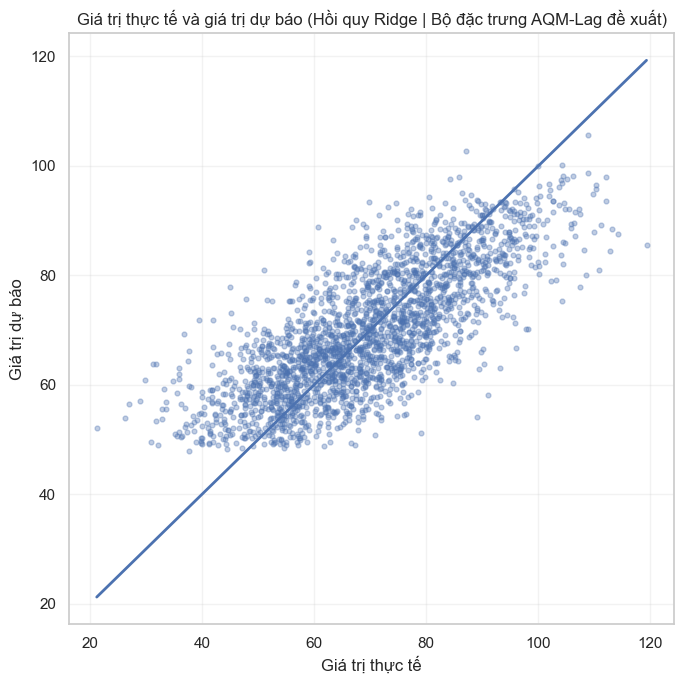


### Hình 10 - Giá trị thực tế và giá trị dự báo

**Tệp đã lưu**
- `figure_10_actual_vs_predicted.png`


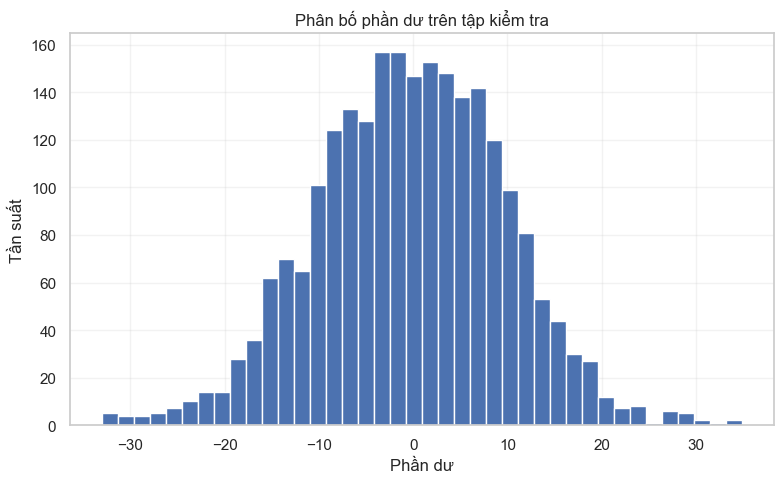


### Hình 11 - Phân bố phần dư trên tập kiểm tra

**Tệp đã lưu**
- `figure_11_residual_histogram.png`


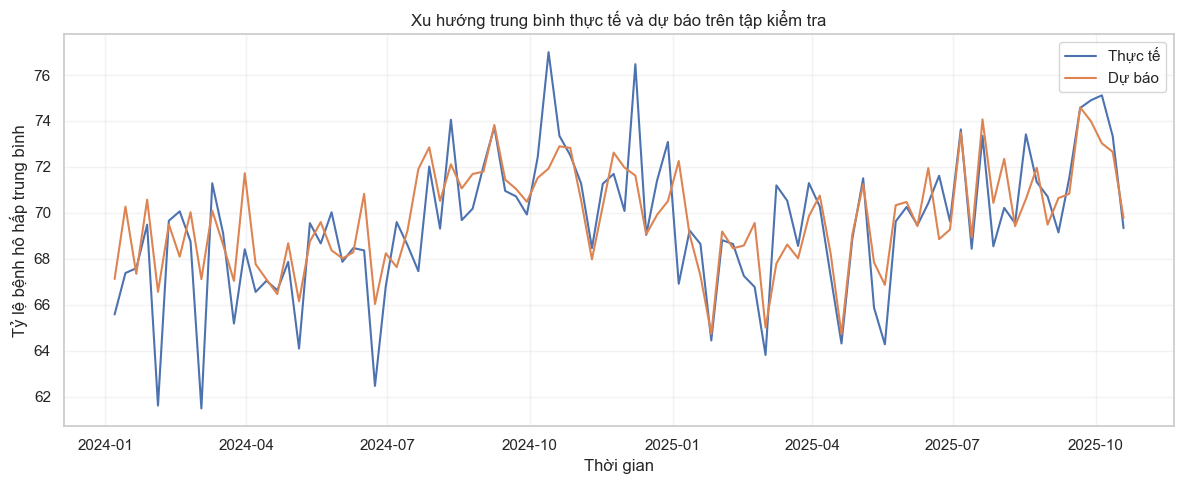


### Hình 12 - Xu hướng trung bình thực tế và dự báo trên tập kiểm tra

**Tệp đã lưu**
- `figure_12_global_actual_vs_predicted_over_time.png`



### Phụ lục - Top 10 đặc trưng quan trọng theo phương pháp hoán vị

**Tệp đã lưu**
- `tables/supp_top10_permutation_importance.csv` giữ dữ liệu/tên kỹ thuật để tái lập kết quả
- `word_table_docx/supp_top10_permutation_importance.docx` dùng tên cột tiếng Việt nếu bảng không quá dài
- `word_table_images/supp_top10_permutation_importance.png` dùng tên cột tiếng Việt nếu bảng không quá dài


,Đặc trưng,Mức quan trọng trung bình,Độ lệch chuẩn mức quan trọng
13,PM2.5 (µg/m³),6.191,0.11
49,Chỉ số căng thẳng AQM,1.54,0.067
8,Lượng mưa (mm),0.296,0.024
52,Tương tác lượng mưa và lũ lụt,0.223,0.023
7,Bất thường nhiệt độ (°C),0.145,0.017
14,Chỉ số chất lượng không khí,0.078,0.014
16,GDP bình quân đầu người (USD),0.075,0.015
31,Nhiệt độ trung bình (°C) (trễ 2 tuần),0.069,0.019
44,Số sự kiện thời tiết cực đoan (trễ 4 tuần),0.067,0.011
5,Tuần,0.058,0.006


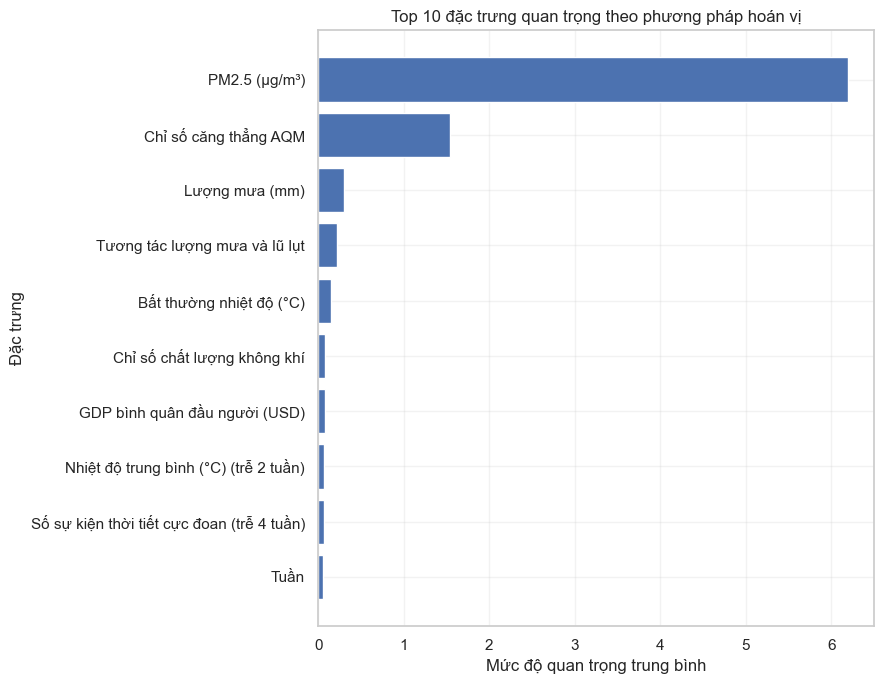


### Hình 13 - Top 10 đặc trưng quan trọng theo phương pháp hoán vị

**Tệp đã lưu**
- `figure_13_top_permutation_importance.png`


In [9]:
# =========================
# 8) Best-model diagnostics
# =========================
print_step("STEP 6 - Best model diagnostics")

X_test_best = test_df[best_features].copy()
y_test_best = test_df[TARGET].copy()
pred_test_best = best_obj["pred_test"]

# Full test predictions are supplementary because they are row-level outputs.
prediction_df = test_df[["country_name", "region", "income_level", "date", TARGET]].copy()
prediction_df["prediction"] = pred_test_best
prediction_df["residual"] = prediction_df[TARGET] - prediction_df["prediction"]
save_df(prediction_df, "table_13_test_predictions", index=False)

def grouped_error_table(pred_df, group_col):
    """Compute test-set errors by a grouping variable."""
    return (
        pred_df.groupby(group_col)
        .apply(lambda g: pd.Series({
            "n": len(g),
            "MAE": mean_absolute_error(g[TARGET], g["prediction"]),
            "RMSE": rmse(g[TARGET], g["prediction"]),
            "mean_residual": float(g["residual"].mean()),
            "median_abs_error": float(np.median(np.abs(g["residual"])))
        }))
        .reset_index()
        .sort_values("RMSE", ascending=False)
    )

# Supplementary subgroup diagnostics.
error_by_region = grouped_error_table(prediction_df, "region")
error_by_income = grouped_error_table(prediction_df, "income_level")
error_by_country = grouped_error_table(prediction_df, "country_name")

save_df(error_by_region, "supp_10_test_error_by_region", index=False)
save_df(error_by_income, "supp_11_test_error_by_income_level", index=False)
save_df(error_by_country, "supp_12_test_error_by_country", index=False)

# Export data for the dynamic Streamlit dashboard.
df.to_csv(os.path.join(DASH_DIR, "dashboard_data.csv"), index=False, encoding="utf-8-sig")
prediction_df.to_csv(os.path.join(DASH_DIR, "test_predictions.csv"), index=False, encoding="utf-8-sig")

# Figure 10: actual vs predicted.
plt.figure(figsize=(7, 7))
plt.scatter(y_test_best, pred_test_best, alpha=0.35, s=12)
lims = [
    min(float(y_test_best.min()), float(pred_test_best.min())),
    max(float(y_test_best.max()), float(pred_test_best.max()))
]
plt.plot(lims, lims, linewidth=2)
plt.title(f"Giá trị thực tế và giá trị dự báo ({format_model_feature_label(best_model_name, best_feature_set)})")
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự báo")
finalize_figure(os.path.join(FIG_DIR, "figure_10_actual_vs_predicted.png"))
show_saved_figure("Hình 10 - Giá trị thực tế và giá trị dự báo", "figure_10_actual_vs_predicted")

# Figure 11: residual distribution.
plt.figure(figsize=(8, 5))
plt.hist(prediction_df["residual"], bins=40)
plt.title("Phân bố phần dư trên tập kiểm tra")
plt.xlabel("Phần dư")
plt.ylabel("Tần suất")
finalize_figure(os.path.join(FIG_DIR, "figure_11_residual_histogram.png"))
show_saved_figure("Hình 11 - Phân bố phần dư trên tập kiểm tra", "figure_11_residual_histogram")

# Figure 12: global average actual vs predicted over time.
plot_df = prediction_df.groupby("date", as_index=False).agg(actual=(TARGET, "mean"), predicted=("prediction", "mean"))
plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["actual"], label="Thực tế")
plt.plot(plot_df["date"], plot_df["predicted"], label="Dự báo")
plt.title("Xu hướng trung bình thực tế và dự báo trên tập kiểm tra")
plt.xlabel("Thời gian")
plt.ylabel("Tỷ lệ bệnh hô hấp trung bình")
plt.legend()
plt.grid(alpha=0.25)
finalize_figure(os.path.join(FIG_DIR, "figure_12_global_actual_vs_predicted_over_time.png"))
show_saved_figure("Hình 12 - Xu hướng trung bình thực tế và dự báo trên tập kiểm tra", "figure_12_global_actual_vs_predicted_over_time")

# Permutation importance on raw input features.
perm = permutation_importance(
    best_pipeline,
    X_test_best,
    y_test_best,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_root_mean_squared_error",
)

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

# Full permutation importance is supplementary; top 10 is the main thesis table.
save_df(importance_df, "table_14_permutation_importance", index=False)

top10_importance_df = importance_df.head(10).copy()
show_saved_table(
    top10_importance_df,
    title="Phụ lục - Top 10 đặc trưng quan trọng theo phương pháp hoán vị",
    stem="supp_top10_permutation_importance",
    index=False
)

# Figure 13: top 10 permutation importance.
top_imp = importance_df.head(10).sort_values("importance_mean", ascending=True)
plt.figure(figsize=(9, 7))
plt.barh(top_imp["feature"].map(lambda x: vi_label(x)), top_imp["importance_mean"])
plt.title("Top 10 đặc trưng quan trọng theo phương pháp hoán vị")
plt.xlabel("Mức độ quan trọng trung bình")
plt.ylabel("Đặc trưng")
finalize_figure(os.path.join(FIG_DIR, "figure_13_top_permutation_importance.png"))
show_saved_figure("Hình 13 - Top 10 đặc trưng quan trọng theo phương pháp hoán vị", "figure_13_top_permutation_importance")

In [10]:
# =========================
# 9) Static interactive dashboard HTML
# =========================
print_step("STEP 7 - Build static interactive dashboard")

# Safety note: do not use Plotly's default choropleth map in the thesis dashboard.
# Spatial comparisons are shown with region/country charts instead.

STATIC_CHART_TITLES = DASHBOARD_CHART_TITLES
STATIC_LABELS = DISPLAY_LABELS

df_static = add_vietnamese_display_columns(df)
sample_df_static = add_vietnamese_display_columns(sample_df)

trend_region = df_static.groupby(["year", "region_vi"], as_index=False)["respiratory_disease_rate"].mean()
fig_d01_region_trend = px.line(trend_region, x="year", y="respiratory_disease_rate", color="region_vi", markers=True, title=STATIC_CHART_TITLES["D01"], labels=STATIC_LABELS)

fig_d02_pm25_scatter = px.scatter(sample_df_static, x="pm25_ugm3", y="respiratory_disease_rate", color="income_level_vi", hover_name="country_name", title=STATIC_CHART_TITLES["D02"], labels=STATIC_LABELS, opacity=0.6)

region_summary_static = (
    df_static.groupby("region_vi", as_index=False)
      .agg(mean_resp=("respiratory_disease_rate", "mean"), mean_pm25=("pm25_ugm3", "mean"), mean_aqi=("air_quality_index", "mean"), n_countries=("country_name", "nunique"))
      .sort_values("mean_resp", ascending=False)
)
fig_d03_region_bar = px.bar(region_summary_static, x="region_vi", y="mean_resp", color="region_vi", hover_data={"n_countries": True, "mean_pm25": ":.2f", "mean_aqi": ":.2f", "mean_resp": ":.2f"}, title=STATIC_CHART_TITLES["D03"], labels=STATIC_LABELS)
fig_d03_region_bar.update_layout(showlegend=False)

country_summary_static = add_vietnamese_display_columns(country_summary).sort_values("mean_resp", ascending=False)
fig_d04_country_ranking = px.bar(country_summary_static, x="country_name", y="mean_resp", color="region_vi", hover_data={"country_code": True, "income_level_vi": True, "mean_pm25": ":.2f", "mean_aqi": ":.2f", "mean_resp": ":.2f"}, title=STATIC_CHART_TITLES["D04"], labels=STATIC_LABELS)
fig_d04_country_ranking.update_layout(xaxis_tickangle=-45)

fig_d05_income_box = px.box(df_static, x="income_level_vi", y="respiratory_disease_rate", color="income_level_vi", title=STATIC_CHART_TITLES["D05"], labels=STATIC_LABELS)

html_blocks = [
    fig_d01_region_trend.to_html(full_html=False, include_plotlyjs="cdn"),
    fig_d02_pm25_scatter.to_html(full_html=False, include_plotlyjs=False),
    fig_d03_region_bar.to_html(full_html=False, include_plotlyjs=False),
    fig_d04_country_ranking.to_html(full_html=False, include_plotlyjs=False),
    fig_d05_income_box.to_html(full_html=False, include_plotlyjs=False),
]

dashboard_html = f"""
<!DOCTYPE html>
<html lang="vi">
<head>
  <meta charset="utf-8" />
  <title>Bảng điều khiển phân tích chất lượng không khí, khí tượng và bệnh hô hấp</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; }}
    h1, h2 {{ margin-bottom: 8px; }}
    .note {{ background: #f5f5f5; padding: 12px; border-radius: 8px; }}
    .block {{ margin-top: 24px; margin-bottom: 36px; }}
  </style>
</head>
<body>
  <h1>Bảng điều khiển phân tích chất lượng không khí, khí tượng và bệnh hô hấp</h1>
  <div class="note">
    <p><strong>Chủ đề:</strong> Phân tích mối liên hệ giữa chất lượng không khí, các yếu tố khí tượng và bệnh hô hấp bằng học máy.</p>
    <p><strong>Hướng đề xuất:</strong> AQM-Lag (đặc trưng độ trễ + chỉ số căng thẳng AQM + biến tương tác).</p>
    <p><strong>Mô hình tốt nhất trên tập kiểm định:</strong> {vi_label(best_model_name)} + {vi_label(best_feature_set)}</p>
    <p><strong>Ghi chú bản đồ:</strong> Bảng điều khiển không sử dụng bản đồ nền mặc định; so sánh không gian được thể hiện bằng biểu đồ vùng/quốc gia.</p>
  </div>
  <div class="block">{html_blocks[0]}</div>
  <div class="block">{html_blocks[1]}</div>
  <div class="block">{html_blocks[2]}</div>
  <div class="block">{html_blocks[3]}</div>
  <div class="block">{html_blocks[4]}</div>
</body>
</html>
"""

save_text(dashboard_html, os.path.join(DASH_DIR, "dashboard_climate_respiratory.html"))



STEP 7 - Build static interactive dashboard


In [11]:
# =========================
# 10) Dynamic Streamlit dashboard app
# =========================
print_step("STEP 8 - Write dynamic Streamlit dashboard app")



streamlit_app_code = r'''
import streamlit as st
import pandas as pd
import plotly.express as px
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

APP_TITLE = "Bảng điều khiển phân tích chất lượng không khí, khí tượng và bệnh hô hấp"

CHART_TITLES = {
    "D01": "D01. Xu hướng tỷ lệ bệnh hô hấp theo năm và vùng",
    "D02": "D02. PM2.5 và tỷ lệ bệnh hô hấp",
    "D03": "D03. Tỷ lệ bệnh hô hấp trung bình theo vùng",
    "D04": "D04. Xếp hạng quốc gia theo tỷ lệ bệnh hô hấp trung bình",
    "D05": "D05. Phân bố tỷ lệ bệnh hô hấp theo nhóm thu nhập",
    "D06": "D06. Giá trị thực tế và dự báo trên tập kiểm tra",
    "D07": "D07. Xu hướng trung bình thực tế và dự báo trên tập kiểm tra",
    "D08": "D08. RMSE trên tập kiểm tra theo vùng",
}

LABELS = {
    "year": "Năm",
    "date": "Thời gian",
    "region": "Vùng địa lý",
    "country_name": "Quốc gia",
    "income_level": "Nhóm thu nhập",
    "region_vi": "Vùng địa lý",
    "income_level_vi": "Nhóm thu nhập",
    "pm25_ugm3": "PM2.5 (µg/m³)",
    "air_quality_index": "Chỉ số chất lượng không khí",
    "respiratory_disease_rate": "Tỷ lệ bệnh hô hấp",
    "mean_resp": "Tỷ lệ bệnh hô hấp trung bình",
    "prediction": "Giá trị dự báo",
    "actual": "Giá trị thực tế",
    "predicted": "Giá trị dự báo",
    "residual": "Phần dư",
    "RMSE": "RMSE",
    "MAE": "MAE",
    "R2": "R²",
    "n_records": "Số bản ghi",
    "n_countries": "Số quốc gia",
    "mean_pm25": "PM2.5 trung bình (µg/m³)",
    "mean_aqi": "AQI trung bình",
}


INCOME_LABELS = {
    "High": "Thu nhập cao",
    "High income": "Thu nhập cao",
    "Low": "Thu nhập thấp",
    "Low income": "Thu nhập thấp",
    "Lower-Middle": "Thu nhập trung bình thấp",
    "Lower middle income": "Thu nhập trung bình thấp",
    "Upper-Middle": "Thu nhập trung bình cao",
    "Upper middle income": "Thu nhập trung bình cao",
    "Middle": "Thu nhập trung bình",
}

REGION_LABELS = {
    "Africa": "Châu Phi",
    "Asia": "Châu Á",
    "Asia Pacific": "Châu Á - Thái Bình Dương",
    "East Asia": "Đông Á",
    "South Asia": "Nam Á",
    "Southeast Asia": "Đông Nam Á",
    "Central Asia": "Trung Á",
    "Europe": "Châu Âu",
    "North America": "Bắc Mỹ",
    "South America": "Nam Mỹ",
    "Latin America": "Mỹ Latinh",
    "Latin America & Caribbean": "Mỹ Latinh và Caribe",
    "Middle East": "Trung Đông",
    "Middle East & North Africa": "Trung Đông và Bắc Phi",
    "Oceania": "Châu Đại Dương",
    "Sub-Saharan Africa": "Châu Phi cận Sahara",
}

def vi_region(value):
    return REGION_LABELS.get(value, value)

def vi_income(value):
    return INCOME_LABELS.get(value, value)

def add_vietnamese_display_columns(dataframe):
    display_df = dataframe.copy()
    if "region" in display_df.columns:
        display_df["region_vi"] = display_df["region"].map(vi_region)
    if "income_level" in display_df.columns:
        display_df["income_level_vi"] = display_df["income_level"].map(vi_income)
    return display_df

DASHBOARD_MAPPING = pd.DataFrame([
    {"Mã": "D01", "Biểu đồ": CHART_TITLES["D01"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_02_annual_respiratory_trend; figure_04_respiratory_by_region"},
    {"Mã": "D02", "Biểu đồ": CHART_TITLES["D02"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_06_pm25_vs_respiratory"},
    {"Mã": "D03", "Biểu đồ": CHART_TITLES["D03"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_04_respiratory_by_region"},
    {"Mã": "D04", "Biểu đồ": CHART_TITLES["D04"], "Liên hệ báo cáo Word/tệp đầu ra": "table_07_country_summary"},
    {"Mã": "D05", "Biểu đồ": CHART_TITLES["D05"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_03_respiratory_by_income"},
    {"Mã": "D06", "Biểu đồ": CHART_TITLES["D06"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_10_actual_vs_predicted"},
    {"Mã": "D07", "Biểu đồ": CHART_TITLES["D07"], "Liên hệ báo cáo Word/tệp đầu ra": "figure_12_global_actual_vs_predicted_over_time"},
    {"Mã": "D08", "Biểu đồ": CHART_TITLES["D08"], "Liên hệ báo cáo Word/tệp đầu ra": "supp_10_test_error_by_region"},
])

AQM_LAG_FEATURE_TABLE = pd.DataFrame([
    {
        "Nhóm đặc trưng": "Biến gốc hiện tại",
        "Biến/thành phần": "country_name, region, income_level, year, month, week, temperature_celsius, temp_anomaly_celsius, precipitation_mm, heat_wave_days, drought_indicator, flood_indicator, extreme_weather_events, pm25_ugm3, air_quality_index, healthcare_access_index, gdp_per_capita_usd, mental_health_index, food_security_index",
        "Ý nghĩa": "Phản ánh điều kiện môi trường, khí tượng và bối cảnh quốc gia tại tuần quan sát."
    },
    {
        "Nhóm đặc trưng": "Đặc trưng trễ",
        "Biến/thành phần": "Các độ trễ 1, 2 và 4 tuần của respiratory_disease_rate, pm25_ugm3, air_quality_index, temperature_celsius, temp_anomaly_celsius, precipitation_mm, heat_wave_days, extreme_weather_events",
        "Ý nghĩa": "Giúp mô hình nắm bắt tác động trì hoãn của ô nhiễm không khí và khí tượng lên bệnh hô hấp."
    },
    {
        "Nhóm đặc trưng": "Trung bình trượt 4 tuần",
        "Biến/thành phần": "respiratory_disease_rate_roll4_mean, pm25_ugm3_roll4_mean, air_quality_index_roll4_mean, temp_anomaly_celsius_roll4_mean",
        "Ý nghĩa": "Phản ánh mức phơi nhiễm hoặc xu hướng nền ngắn hạn trước tuần dự báo."
    },
    {
        "Nhóm đặc trưng": "Mã hóa mùa vụ",
        "Biến/thành phần": "season_sin, season_cos",
        "Ý nghĩa": "Biểu diễn chu kỳ mùa vụ theo tuần trong năm, giúp mô hình hiểu tính lặp lại theo thời gian."
    },
    {
        "Nhóm đặc trưng": "Chỉ số tổng hợp",
        "Biến/thành phần": "aqm_stress_index",
        "Ý nghĩa": "Tóm tắt áp lực môi trường hô hấp từ PM2.5, AQI, bất thường nhiệt, nắng nóng và thời tiết cực đoan."
    },
    {
        "Nhóm đặc trưng": "Biến tương tác",
        "Biến/thành phần": "pm25_x_temperature, aqi_x_heatwave, precip_x_flood",
        "Ý nghĩa": "Cho phép mô hình nhận diện tác động kết hợp giữa các yếu tố môi trường."
    },
])

AQM_STRESS_WEIGHTS = pd.DataFrame([
    {"Thành phần": "PM2.5", "Biến": "pm25_ugm3", "Trọng số": 0.35},
    {"Thành phần": "AQI", "Biến": "air_quality_index", "Trọng số": 0.25},
    {"Thành phần": "Bất thường nhiệt độ", "Biến": "temp_anomaly_celsius", "Trọng số": 0.15},
    {"Thành phần": "Số ngày nắng nóng", "Biến": "heat_wave_days", "Trọng số": 0.15},
    {"Thành phần": "Thời tiết cực đoan", "Biến": "extreme_weather_events", "Trọng số": 0.10},
])


st.set_page_config(page_title=APP_TITLE, layout="wide")

BASE_DIR = Path(__file__).resolve().parent
DATA_PATH = BASE_DIR / "dashboard_data.csv"
PRED_PATH = BASE_DIR / "test_predictions.csv"

if not DATA_PATH.exists():
    st.error(f"Không tìm thấy file dữ liệu: {DATA_PATH}")
    st.stop()

if not PRED_PATH.exists():
    st.error(f"Không tìm thấy file dự báo: {PRED_PATH}")
    st.stop()

@st.cache_data
def load_data():
    data = pd.read_csv(DATA_PATH, parse_dates=["date"])
    pred = pd.read_csv(PRED_PATH, parse_dates=["date"])
    return data, pred

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

df, pred_df = load_data()
df = add_vietnamese_display_columns(df)
pred_df = add_vietnamese_display_columns(pred_df)

st.title(APP_TITLE)
st.caption("Sản phẩm tương tác")
st.sidebar.header("Bộ lọc dữ liệu")

year_min = int(df["year"].min())
year_max = int(df["year"].max())
year_range = st.sidebar.slider("Chọn khoảng năm", min_value=year_min, max_value=year_max, value=(year_min, year_max))

regions = sorted(df["region_vi"].dropna().unique())
selected_regions = st.sidebar.multiselect("Chọn vùng địa lý", regions, default=regions)

income_levels = sorted(df["income_level_vi"].dropna().unique())
selected_income = st.sidebar.multiselect("Chọn nhóm thu nhập", income_levels, default=income_levels)

countries = sorted(df["country_name"].dropna().unique())
selected_countries = st.sidebar.multiselect("Chọn quốc gia", countries, default=countries)

filtered_df = df[
    (df["year"] >= year_range[0]) &
    (df["year"] <= year_range[1]) &
    (df["region_vi"].isin(selected_regions)) &
    (df["income_level_vi"].isin(selected_income)) &
    (df["country_name"].isin(selected_countries))
].copy()

filtered_pred = pred_df[
    (pred_df["date"].dt.year >= year_range[0]) &
    (pred_df["date"].dt.year <= year_range[1]) &
    (pred_df["region_vi"].isin(selected_regions)) &
    (pred_df["income_level_vi"].isin(selected_income)) &
    (pred_df["country_name"].isin(selected_countries))
].copy()

if filtered_df.empty:
    st.warning("Không có dữ liệu phù hợp với bộ lọc hiện tại.")
    st.stop()

col1, col2, col3, col4 = st.columns(4)
col1.metric("Số bản ghi", f"{len(filtered_df):,}")
col2.metric("Số quốc gia", filtered_df["country_name"].nunique())
col3.metric("PM2.5 trung bình (µg/m³)", f"{filtered_df['pm25_ugm3'].mean():.2f}")
col4.metric("Tỷ lệ bệnh hô hấp trung bình", f"{filtered_df['respiratory_disease_rate'].mean():.2f}")

st.info(
    "Các biểu đồ dự báo trong dashboard được xây dựng trên bộ đặc trưng AQM-Lag, "
    "tức là không chỉ sử dụng biến môi trường tại tuần hiện tại mà còn bổ sung "
    "độ trễ theo thời gian, trung bình trượt, mùa vụ, chỉ số tổng hợp và biến tương tác."
)

with st.expander("Giải thích bộ đặc trưng AQM-Lag được sử dụng trong mô hình dự báo", expanded=True):
    st.markdown("""
    ### AQM-Lag là gì?

    **AQM-Lag** là bộ đặc trưng đề xuất của đồ án, trong đó **AQM** là viết tắt của
    *Air Quality and Meteorology* — chất lượng không khí và khí tượng, còn **Lag**
    nhấn mạnh việc bổ sung các đặc trưng trễ theo thời gian.

    Thay vì chỉ sử dụng các biến tại tuần hiện tại, AQM-Lag kết hợp thêm:
    - Đặc trưng trễ 1, 2 và 4 tuần;
    - Trung bình trượt 4 tuần;
    - Mã hóa mùa vụ bằng `season_sin` và `season_cos`;
    - Chỉ số tổng hợp `aqm_stress_index`;
    - Các biến tương tác giữa ô nhiễm không khí và khí tượng.

    Cách thiết kế này phù hợp vì dữ liệu của đề tài có cấu trúc theo tuần và theo quốc gia.
    Ảnh hưởng của ô nhiễm không khí hoặc biến động khí tượng đến bệnh hô hấp có thể không
    xuất hiện ngay lập tức, mà có thể có độ trễ hoặc tác động tích lũy ngắn hạn.
    """)

    st.dataframe(AQM_LAG_FEATURE_TABLE, use_container_width=True, hide_index=True)

    st.markdown("""
    ### AQM Stress Index

    `aqm_stress_index` là chỉ số tổng hợp phản ánh mức căng thẳng môi trường hô hấp
    trong từng tuần. Chỉ số này kết hợp các yếu tố ô nhiễm không khí, bất thường nhiệt,
    nắng nóng và thời tiết cực đoan.
    """)

    st.dataframe(AQM_STRESS_WEIGHTS, use_container_width=True, hide_index=True)

    st.markdown("""
    ### Vì sao chọn AQM-Lag cho các biểu đồ dự báo?

    Bộ đặc trưng này được chọn vì nó giúp mô hình nhìn bài toán theo nhiều lớp thông tin hơn:

    1. **Lớp hiện tại**: điều kiện môi trường và bối cảnh quốc gia trong tuần quan sát.
    2. **Lớp thời gian**: các giá trị trễ và trung bình trượt giúp phản ánh hiệu ứng trì hoãn.
    3. **Lớp mùa vụ**: `season_sin` và `season_cos` giúp mô hình nhận diện chu kỳ trong năm.
    4. **Lớp tổng hợp**: `aqm_stress_index` tóm tắt áp lực môi trường hô hấp.
    5. **Lớp tương tác**: các biến như `pm25_x_temperature` hoặc `precip_x_flood`
       biểu diễn tình huống nhiều yếu tố môi trường xuất hiện đồng thời.

    Vì vậy, AQM-Lag không chỉ phục vụ mục tiêu dự báo mà còn giúp giải thích vì sao
    các yếu tố môi trường có thể liên hệ với tỷ lệ bệnh hô hấp.
    """)

st.divider()

left, right = st.columns(2)

with left:
    annual_trend = filtered_df.groupby(["year", "region_vi"], as_index=False)["respiratory_disease_rate"].mean()
    fig_d01_trend = px.line(
        annual_trend,
        x="year",
        y="respiratory_disease_rate",
        color="region_vi",
        markers=True,
        title=CHART_TITLES["D01"],
        labels=LABELS,
    )
    st.plotly_chart(fig_d01_trend, use_container_width=True)

with right:
    fig_d02_pm25 = px.scatter(
        filtered_df,
        x="pm25_ugm3",
        y="respiratory_disease_rate",
        color="income_level_vi",
        hover_name="country_name",
        title=CHART_TITLES["D02"],
        labels=LABELS,
        opacity=0.6,
    )
    st.plotly_chart(fig_d02_pm25, use_container_width=True)

left, right = st.columns(2)

with left:
    region_summary = (
        filtered_df
        .groupby("region_vi", as_index=False)
        .agg(
            n_records=("respiratory_disease_rate", "size"),
            n_countries=("country_name", "nunique"),
            mean_resp=("respiratory_disease_rate", "mean"),
            mean_pm25=("pm25_ugm3", "mean"),
            mean_aqi=("air_quality_index", "mean"),
        )
        .sort_values("mean_resp", ascending=False)
    )
    fig_d03_region = px.bar(
        region_summary,
        x="region_vi",
        y="mean_resp",
        color="region_vi",
        hover_data={"n_records": True, "n_countries": True, "mean_pm25": ":.2f", "mean_aqi": ":.2f", "mean_resp": ":.2f"},
        title=CHART_TITLES["D03"],
        labels=LABELS,
    )
    fig_d03_region.update_layout(showlegend=False)
    st.plotly_chart(fig_d03_region, use_container_width=True)

with right:
    country_summary_filtered = (
        filtered_df
        .groupby(["country_code", "country_name", "region_vi", "income_level_vi"], as_index=False)
        .agg(mean_resp=("respiratory_disease_rate", "mean"), mean_pm25=("pm25_ugm3", "mean"), mean_aqi=("air_quality_index", "mean"))
        .sort_values("mean_resp", ascending=False)
    )
    fig_d04_country = px.bar(
        country_summary_filtered,
        x="country_name",
        y="mean_resp",
        color="region_vi",
        hover_data={"country_code": True, "income_level_vi": True, "mean_pm25": ":.2f", "mean_aqi": ":.2f", "mean_resp": ":.2f"},
        title=CHART_TITLES["D04"],
        labels=LABELS,
    )
    fig_d04_country.update_layout(xaxis_tickangle=-45)
    st.plotly_chart(fig_d04_country, use_container_width=True)

fig_d05_income = px.box(
    filtered_df,
    x="income_level_vi",
    y="respiratory_disease_rate",
    color="income_level_vi",
    title=CHART_TITLES["D05"],
    labels=LABELS,
)
st.plotly_chart(fig_d05_income, use_container_width=True)

st.divider()

st.subheader("Đánh giá dự báo trên tập kiểm tra")
st.caption("Các giá trị dự báo được tạo từ mô hình cuối cùng sử dụng bộ đặc trưng AQM_Lag_proposed.")

if filtered_pred.empty:
    st.info("Không có bản ghi dự báo phù hợp với bộ lọc hiện tại.")
else:
    mae = mean_absolute_error(filtered_pred["respiratory_disease_rate"], filtered_pred["prediction"])
    model_rmse = rmse(filtered_pred["respiratory_disease_rate"], filtered_pred["prediction"])

    if len(filtered_pred) >= 2:
        model_r2 = r2_score(filtered_pred["respiratory_disease_rate"], filtered_pred["prediction"])
        r2_text = f"{model_r2:.3f}"
    else:
        r2_text = "NA"

    c1, c2, c3 = st.columns(3)
    c1.metric("MAE", f"{mae:.3f}")
    c2.metric("RMSE", f"{model_rmse:.3f}")
    c3.metric("R²", r2_text)

    left, right = st.columns(2)

    with left:
        fig_d06_pred_scatter = px.scatter(
            filtered_pred,
            x="respiratory_disease_rate",
            y="prediction",
            color="region_vi",
            hover_name="country_name",
            title=CHART_TITLES["D06"],
            labels=LABELS,
        )
        fig_d06_pred_scatter.add_shape(
            type="line",
            x0=filtered_pred["respiratory_disease_rate"].min(),
            y0=filtered_pred["respiratory_disease_rate"].min(),
            x1=filtered_pred["respiratory_disease_rate"].max(),
            y1=filtered_pred["respiratory_disease_rate"].max(),
            line=dict(dash="dash"),
        )
        fig_d06_pred_scatter.update_layout(xaxis_title="Giá trị thực tế", yaxis_title="Giá trị dự báo")
        st.plotly_chart(fig_d06_pred_scatter, use_container_width=True)

    with right:
        pred_trend = filtered_pred.groupby("date", as_index=False).agg(actual=("respiratory_disease_rate", "mean"), predicted=("prediction", "mean"))
        fig_d07_pred_trend = px.line(
            pred_trend.rename(columns={"actual": "Giá trị thực tế", "predicted": "Giá trị dự báo"}),
            x="date",
            y=["Giá trị thực tế", "Giá trị dự báo"],
            markers=True,
            title=CHART_TITLES["D07"],
            labels=LABELS,
        )
        st.plotly_chart(fig_d07_pred_trend, use_container_width=True)

    error_by_region = (
        filtered_pred
        .groupby("region_vi")
        .apply(lambda g: pd.Series({
            "n": len(g),
            "MAE": mean_absolute_error(g["respiratory_disease_rate"], g["prediction"]),
            "RMSE": rmse(g["respiratory_disease_rate"], g["prediction"]),
            "mean_residual": g["residual"].mean(),
        }))
        .reset_index()
        .sort_values("RMSE", ascending=False)
    )

    fig_d08_error = px.bar(
        error_by_region,
        x="region_vi",
        y="RMSE",
        color="region_vi",
        hover_data={"n": True, "MAE": ":.3f", "RMSE": ":.3f", "mean_residual": ":.3f"},
        title=CHART_TITLES["D08"],
        labels=LABELS,
    )
    fig_d08_error.update_layout(showlegend=False)
    st.plotly_chart(fig_d08_error, use_container_width=True)

    with st.expander("Bảng sai số dự báo theo vùng"):
        st.dataframe(error_by_region.rename(columns=LABELS), use_container_width=True)

with st.expander("Bảng ánh xạ bảng điều khiển"):
    st.dataframe(DASHBOARD_MAPPING, use_container_width=True)
with st.expander("Ghi chú diễn giải kết quả AQM-Lag"):
    st.markdown("""
    Trong thực nghiệm của đồ án, AQM-Lag được xem là phần đề xuất chính về mặt thiết kế đặc trưng.
    Kết quả ablation cho thấy bộ đặc trưng này chưa tạo ra cải thiện RMSE rõ rệt so với bộ biến gốc.
    Tuy nhiên, trong phân tích độ quan trọng hoán vị, `aqm_stress_index` xuất hiện trong nhóm đặc trưng
    quan trọng nhất sau PM2.5. Điều này cho thấy AQM-Lag có giá trị ở khả năng tổ chức và giải thích
    không gian đặc trưng, thay vì chỉ được đánh giá bằng mức cải thiện sai số dự báo.
    """)
    

'''

save_text(streamlit_app_code, os.path.join(DASH_DIR, "app.py"))
print(f"[SUCCESS] Streamlit app saved to: {os.path.join(DASH_DIR, 'app.py')}")



STEP 8 - Write dynamic Streamlit dashboard app
[SUCCESS] Streamlit app saved to: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus\dashboard\app.py


In [12]:
# =========================
# 11) Auto summary and output manifest
# =========================
print_step("STEP 9 - Write auto summary for thesis drafting")

best_test_row = test_rank[
    (test_rank["feature_set"] == best_feature_set) &
    (test_rank["model"] == best_model_name)
].iloc[0]

summary_md = f"""
# Tóm tắt tự động phục vụ viết báo cáo

## 1. Tổng quan bộ dữ liệu
- Số dòng: {df.shape[0]}
- Số cột: {df.shape[1]}
- Số quốc gia: {df['country_name'].nunique()}
- Số vùng địa lý: {df['region'].nunique()}
- Khoảng thời gian: {df['date'].min().date()} đến {df['date'].max().date()}
- Số giá trị thiếu: {int(df.isna().sum().sum())}

## 2. Phương pháp đề xuất
Phương pháp đề xuất là **AQM-Lag**, kết hợp:
1. Các biến khí hậu, chất lượng không khí và kinh tế - xã hội gốc.
2. Đặc trưng độ trễ 1, 2 và 4 tuần.
3. Trung bình trượt của các biến hô hấp và môi trường quan trọng.
4. Mã hóa mùa vụ bằng sin/cos của số tuần trong năm.
5. Chỉ số tổng hợp **aqm_stress_index** xây dựng từ PM2.5, AQI, bất thường nhiệt độ, số ngày nắng nóng và sự kiện thời tiết cực đoan.
6. Các biến tương tác đơn giản: PM2.5 x nhiệt độ, AQI x nắng nóng, lượng mưa x lũ lụt.

## 3. Phân chia dữ liệu
- Huấn luyện: 2015-2021
- Kiểm định: 2022-2023
- Kiểm tra: 2024-2025

## 4. Mô hình tốt nhất trên tập kiểm định
- Bộ đặc trưng: {vi_label(best_feature_set)}
- Mô hình: {vi_label(best_model_name)}

## 5. Chỉ số đánh giá trên tập kiểm tra
- MAE: {best_test_row['MAE']:.4f}
- RMSE: {best_test_row['RMSE']:.4f}
- R2: {best_test_row['R2']:.4f}
- MAPE (%): {best_test_row['MAPE_percent']:.4f}

## 6. Lưu ý diễn giải quan trọng
AQM-Lag là chiến lược tổ chức bộ đặc trưng có cấu trúc. Cần diễn giải đây là cách kết hợp thông tin độ trễ, trung bình trượt, mùa vụ, chỉ số căng thẳng và tương tác; không phải một thuật toán học máy độc lập mới.

## 7. Gợi ý sử dụng đầu ra theo chương
- Chương 1: table_01_dataset_overview, table_02_variable_groups, table_03_missing_values, table_05_outlier_summary
- Chương 3: table_08_time_split, supp_aqm_stress_weights, table_09_feature_catalog
- Chương 4: table_15_ablation_best_by_feature_set, table_11_validation_model_ranking, table_12_test_model_ranking, supp_top10_permutation_importance
- Hình kết quả: figure_10_actual_vs_predicted, figure_12_global_actual_vs_predicted_over_time, figure_13_top_permutation_importance, figure_14_validation_rmse_by_feature_set
- Demo/sản phẩm: dashboard/dashboard_climate_respiratory.html và dashboard/app.py
- Ghi chú bảng điều khiển: không dùng bản đồ nền choropleth mặc định; so sánh không gian được thể hiện bằng biểu đồ vùng/quốc gia.
- Tài nguyên phụ lục: các tệp có tiền tố supp_*
- Danh mục biểu đồ bảng điều khiển: supp_16_dashboard_chart_catalog
- Ánh xạ đầu ra cho Word: supp_17_word_output_mapping
- Ảnh bảng sẵn sàng chèn Word: word_table_images/table_XX_*.png

## 8. Ghi chú
- Các bảng chính dùng tiền tố table_XX_*.
- Các đầu ra trung gian/phụ lục dùng tiền tố supp_XX_*.
- Khi thay đổi phương pháp hoặc cấu hình mô hình, cần chạy lại notebook để toàn bộ bảng và hình nhất quán.
"""

save_text(
    summary_md.strip() + "\n",
    os.path.join(REPORT_DIR, "auto_summary_for_writing.md")
)


# Dashboard-to-report mapping for Word appendix or dashboard section.
dashboard_chart_catalog = pd.DataFrame([
    {"dashboard_id": "D01", "dashboard_title": "Xu hướng tỷ lệ bệnh hô hấp theo năm và vùng", "related_static_output": "figure_02_annual_respiratory_trend.png; figure_04_respiratory_by_region.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D01", "purpose": "Theo dõi xu hướng bệnh hô hấp theo thời gian và vùng địa lý"},
    {"dashboard_id": "D02", "dashboard_title": "PM2.5 và tỷ lệ bệnh hô hấp", "related_static_output": "figure_06_pm25_vs_respiratory.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D02", "purpose": "Khám phá quan hệ giữa ô nhiễm bụi mịn và tỷ lệ bệnh hô hấp"},
    {"dashboard_id": "D03", "dashboard_title": "Tỷ lệ bệnh hô hấp trung bình theo vùng", "related_static_output": "figure_04_respiratory_by_region.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D03", "purpose": "So sánh trung bình tỷ lệ bệnh hô hấp giữa các vùng"},
    {"dashboard_id": "D04", "dashboard_title": "Xếp hạng quốc gia theo tỷ lệ bệnh hô hấp trung bình", "related_static_output": "table_07_country_summary.csv", "word_caption_suggestion": "Hình minh họa bảng điều khiển D04", "purpose": "So sánh các quốc gia theo tỷ lệ bệnh hô hấp trung bình"},
    {"dashboard_id": "D05", "dashboard_title": "Phân bố tỷ lệ bệnh hô hấp theo nhóm thu nhập", "related_static_output": "figure_03_respiratory_by_income.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D05", "purpose": "Quan sát phân bố và ngoại lệ theo nhóm thu nhập"},
    {"dashboard_id": "D06", "dashboard_title": "Giá trị thực tế và dự báo trên tập kiểm tra", "related_static_output": "figure_10_actual_vs_predicted.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D06", "purpose": "Đánh giá mức độ khớp giữa giá trị thực tế và giá trị dự báo"},
    {"dashboard_id": "D07", "dashboard_title": "Xu hướng trung bình thực tế và dự báo trên tập kiểm tra", "related_static_output": "figure_12_global_actual_vs_predicted_over_time.png", "word_caption_suggestion": "Hình minh họa bảng điều khiển D07", "purpose": "Theo dõi sai khác dự báo theo thời gian"},
    {"dashboard_id": "D08", "dashboard_title": "RMSE trên tập kiểm tra theo vùng", "related_static_output": "supp_10_test_error_by_region.csv", "word_caption_suggestion": "Hình minh họa bảng điều khiển D08", "purpose": "Đánh giá sai số mô hình theo vùng địa lý"},
])
save_df(dashboard_chart_catalog, "supp_16_dashboard_chart_catalog", index=False)

word_output_mapping = pd.DataFrame([
    {"word_location": "Bảng 1.1", "word_caption": "Tổng quan bộ dữ liệu", "output_file": "table_01_dataset_overview.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 1.2", "word_caption": "Nhóm biến trong bộ dữ liệu", "output_file": "table_02_variable_groups.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 1.3", "word_caption": "Tóm tắt dữ liệu thiếu", "output_file": "table_03_missing_values.csv", "use_in_word": "Chính hoặc phụ lục"},
    {"word_location": "Bảng 3.1", "word_caption": "Phân chia tập huấn luyện, kiểm định và kiểm tra theo thời gian", "output_file": "table_08_time_split.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 3.2", "word_caption": "Thành phần và trọng số của AQM Stress Index", "output_file": "supp_aqm_stress_weights.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 3.3", "word_caption": "Danh mục các bộ đặc trưng", "output_file": "table_09_feature_catalog.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 4.1", "word_caption": "Kết quả loại/bổ sung đặc trưng theo bộ đặc trưng", "output_file": "table_15_ablation_best_by_feature_set.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 4.2", "word_caption": "Xếp hạng mô hình trên tập kiểm định", "output_file": "table_11_validation_model_ranking.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 4.3", "word_caption": "Kết quả mô hình trên tập kiểm tra", "output_file": "table_12_test_model_ranking.csv", "use_in_word": "Chính"},
    {"word_location": "Bảng 4.4", "word_caption": "Top 10 đặc trưng quan trọng theo phương pháp hoán vị", "output_file": "supp_top10_permutation_importance.csv", "use_in_word": "Chính"},
    {"word_location": "Hình 1.1", "word_caption": "Xu hướng tỷ lệ bệnh hô hấp trung bình theo năm", "output_file": "figure_02_annual_respiratory_trend.png", "use_in_word": "Chính"},
    {"word_location": "Hình 1.2", "word_caption": "Tỷ lệ bệnh hô hấp trung bình theo vùng địa lý", "output_file": "figure_04_respiratory_by_region.png", "use_in_word": "Chính"},
    {"word_location": "Hình 4.1", "word_caption": "Giá trị thực tế và giá trị dự báo trên tập kiểm tra", "output_file": "figure_10_actual_vs_predicted.png", "use_in_word": "Chính"},
    {"word_location": "Hình 4.2", "word_caption": "Phân bố phần dư trên tập kiểm tra", "output_file": "figure_11_residual_histogram.png", "use_in_word": "Chính"},
    {"word_location": "Hình 4.3", "word_caption": "Xu hướng trung bình thực tế và dự báo trên tập kiểm tra", "output_file": "figure_12_global_actual_vs_predicted_over_time.png", "use_in_word": "Chính"},
    {"word_location": "Hình 4.4", "word_caption": "Top đặc trưng quan trọng theo phương pháp hoán vị", "output_file": "figure_13_top_permutation_importance.png", "use_in_word": "Chính"},
    {"word_location": "Hình 4.5", "word_caption": "RMSE trên tập kiểm định theo bộ đặc trưng", "output_file": "figure_14_validation_rmse_by_feature_set.png", "use_in_word": "Chính"},
])
save_df(word_output_mapping, "supp_17_word_output_mapping", index=False)

chapter_asset_map = pd.DataFrame([
    {
        "chapter": "Tóm tắt / Đặt vấn đề",
        "recommended_assets": "table_01_dataset_overview.csv; figure_02_annual_respiratory_trend.png"
    },
    {
        "chapter": "Chương 1",
        "recommended_assets": "table_01_dataset_overview.csv; table_02_variable_groups.csv; table_03_missing_values.csv; table_05_outlier_summary.csv; figure_04_respiratory_by_region.png"
    },
    {
        "chapter": "Chương 3",
        "recommended_assets": "table_08_time_split.csv; supp_aqm_stress_weights.csv; table_09_feature_catalog.csv; figure_14_validation_rmse_by_feature_set.png"
    },
    {
        "chapter": "Chương 4",
        "recommended_assets": "table_15_ablation_best_by_feature_set.csv; table_11_validation_model_ranking.csv; table_12_test_model_ranking.csv; supp_top10_permutation_importance.csv; figure_10_actual_vs_predicted.png; figure_12_global_actual_vs_predicted_over_time.png; figure_13_top_permutation_importance.png"
    },
    {
        "chapter": "Phụ lục",
        "recommended_assets": "supp_*.csv; models/best_model_info.json; models/best_model.joblib; dashboard/dashboard_climate_respiratory.html; dashboard/app.py; report/auto_summary_for_writing.md"
    },
])
save_df(chapter_asset_map, "table_16_chapter_asset_map", index=False)

manifest = []
for root, _, files_in_dir in os.walk(OUT_ROOT):
    for name in sorted(files_in_dir):
        manifest.append({"file": os.path.relpath(os.path.join(root, name), OUT_ROOT)})

manifest_df = pd.DataFrame(manifest)
save_df(manifest_df, "table_17_output_manifest", index=False)

print_step("DONE")
print(f"[SUCCESS] All outputs were saved to: {OUT_ROOT}")
print(f"[SUCCESS] Main summary file: {os.path.join(REPORT_DIR, 'auto_summary_for_writing.md')}")
print(f"[SUCCESS] Static dashboard: {os.path.join(DASH_DIR, 'dashboard_climate_respiratory.html')}")
print(f"[SUCCESS] Dynamic dashboard app: {os.path.join(DASH_DIR, 'app.py')}")


STEP 9 - Write auto summary for thesis drafting

DONE
[SUCCESS] All outputs were saved to: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus
[SUCCESS] Main summary file: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus\report\auto_summary_for_writing.md
[SUCCESS] Static dashboard: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus\dashboard\dashboard_climate_respiratory.html
[SUCCESS] Dynamic dashboard app: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus\dashboard\app.py


In [13]:
# =========================
# 12) Submission support files
# =========================
print_step("STEP 10 - Write README, requirements and optional submission zip")
import shutil

STREAMLIT_APP_URL = "https://datnhuyenngoc.streamlit.app"

requirements_text = """
numpy
pandas
matplotlib
seaborn
plotly
scipy
scikit-learn
statsmodels
joblib
streamlit
jinja2
python-docx
openpyxl
""".strip()

save_text(requirements_text + "\n", PROJECT_ROOT / "requirements.txt")
save_text(requirements_text + "\n", OUT_ROOT / "requirements.txt")

readme_text = f"""
# Hướng dẫn chạy và xem sản phẩm đồ án

## 1. Truy cập bảng điều khiển đã triển khai trên Streamlit

Bảng điều khiển động của đồ án đã được triển khai trên Streamlit và có thể truy cập tại:

`{STREAMLIT_APP_URL}`

Bảng điều khiển cho phép xem trực quan các kết quả phân tích, so sánh mô hình và kết quả dự báo nguy cơ bệnh đường hô hấp trên tập kiểm tra.

Lưu ý: Bảng điều khiển là sản phẩm minh họa kết quả phân tích và dự báo từ bộ dữ liệu nghiên cứu. Đây chưa phải là hệ thống dự báo thời gian thực hoặc hệ thống cảnh báo y tế vận hành chính thức.

## 2. Cấu trúc dữ liệu đầu vào

Đặt file dữ liệu `{DATA_FILE_NAME}` theo một trong các vị trí sau:

- Cùng thư mục với notebook.
- Thư mục `data/`.
- Thư mục `datn_huph_input/`.
- Trên Google Colab: `/content/drive/MyDrive/` hoặc `/content/drive/MyDrive/datn_huph_input/`.

## 3. Chạy notebook để tái lập kết quả

Mở `DATN.ipynb` bằng Google Colab hoặc VS Code/Jupyter, sau đó chọn **Run All**.

Kết quả sẽ được lưu trong thư mục:

`{OUTPUT_FOLDER_NAME}/`

Notebook sẽ tự động sinh các bảng, biểu đồ, mô hình đã lưu và các tệp phục vụ báo cáo.

## 4. Chạy bảng điều khiển trên máy cá nhân nếu cần

Trường hợp muốn chạy dashboard trên máy cá nhân, cài thư viện bằng lệnh:

```bash
pip install -r requirements.txt
```

Sau đó chạy Streamlit:

```bash
python -m streamlit run {OUTPUT_FOLDER_NAME}/dashboard/app.py
```

Mở địa chỉ sau trên trình duyệt:

`http://localhost:8501`

## 5. Các thư mục output

- `figures/`: hình biểu đồ dùng trong báo cáo.
- `tables/`: bảng CSV nguồn để mở bằng Excel hoặc kiểm tra lại dữ liệu.
- `word_table_docx/`: bảng Word `.docx` đã định dạng, có thể copy trực tiếp vào báo cáo Word.
- `word_table_images/`: ảnh PNG của các bảng để chèn nhanh vào Word nếu không cần chỉnh sửa bảng.
- `models/`: mô hình học máy đã lưu.
- `report/`: tệp tóm tắt kết quả và thông tin môi trường chạy.
- `dashboard/`: bảng điều khiển HTML và ứng dụng Streamlit.

## 6. Ghi chú phương pháp

Bảng điều khiển sử dụng kết quả phân tích được tạo ra từ notebook. Các kết quả dự báo được trình bày trên tập kiểm tra nhằm minh họa khả năng ứng dụng mô hình học máy trong đánh giá nguy cơ bệnh đường hô hấp.

Dashboard chưa được kết nối với dữ liệu thời gian thực, do đó không nên diễn giải là hệ thống cảnh báo y tế vận hành chính thức.

## 7. Gợi ý sử dụng trong báo cáo Word

- Với biểu đồ, dùng file `.png` trong thư mục `figures/`.
- Với bảng, ưu tiên mở file `.docx` trong `word_table_docx/`, sau đó copy bảng và dán vào báo cáo Word chính.
- File `.csv` trong `tables/` là dữ liệu nguồn để kiểm tra hoặc xử lý lại bằng Excel.
- Ảnh bảng trong `word_table_images/` chỉ nên dùng khi cần chèn nhanh và không cần chỉnh sửa nội dung bảng.
- Xem `tables/supp_17_word_output_mapping.csv` để biết bảng/hình nào nên đặt ở phần nào trong báo cáo Word.

## 8. Ghi chú khi nộp bài

File `{OUTPUT_FOLDER_NAME}.zip` được tạo tự động sau khi chạy notebook. File này chứa toàn bộ kết quả đầu ra của đồ án, bao gồm bảng, biểu đồ, mô hình, báo cáo phụ trợ và dashboard.

Nếu đã triển khai dashboard trên Streamlit, khi nộp bài có thể cung cấp thêm đường dẫn trực tuyến:

`{STREAMLIT_APP_URL}`
"""

save_text(readme_text.strip() + "\n", PROJECT_ROOT / "README_run_project.md")
save_text(readme_text.strip() + "\n", OUT_ROOT / "README_run_project.md")


def make_submission_zip(download_in_colab=False):
    """
    Create a zip package containing the output folder.
    Works in both Google Colab and VS Code/local.

    Set download_in_colab=True if you want Colab to download the zip automatically.
    """
    zip_base = PROJECT_ROOT / OUTPUT_FOLDER_NAME
    zip_file = zip_base.with_suffix(".zip")

    if zip_file.exists():
        zip_file.unlink()

    shutil.make_archive(
        base_name=str(zip_base),
        format="zip",
        root_dir=str(OUT_ROOT)
    )

    print(f"[SUCCESS] Submission zip created: {zip_file}")

    if IN_COLAB and download_in_colab:
        files.download(str(zip_file))

    return zip_file


submission_zip_path = make_submission_zip(download_in_colab=False)

print(f"[SUCCESS] requirements.txt saved to: {PROJECT_ROOT / 'requirements.txt'}")
print(f"[SUCCESS] README saved to: {PROJECT_ROOT / 'README_run_project.md'}")
print(f"[SUCCESS] Submission zip: {submission_zip_path}")


STEP 10 - Write README, requirements and optional submission zip
[SUCCESS] Submission zip created: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus.zip
[SUCCESS] requirements.txt saved to: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\requirements.txt
[SUCCESS] README saved to: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\README_run_project.md
[SUCCESS] Submission zip: d:\Study\2211090019_NguyenMinhHuyen_2211090029_NguyenThiHongNgoc_KHDL1\datn_huph_output_plus.zip
